In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import gc
sns.set_theme()
gc.enable()

In [2]:
main_data=pd.read_csv('application_train.csv')
main_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
numerical_features=main_data.select_dtypes(exclude='object').columns
encoded_features=pd.Index(['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                           'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
                           'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
                           'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
                           'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
                           'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
                           'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
                           'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
                           'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
                           'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
                           'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
                           'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'])
categorical_features=main_data.columns.difference(numerical_features)
numerical_features=numerical_features.difference(encoded_features)

# Numerical Features

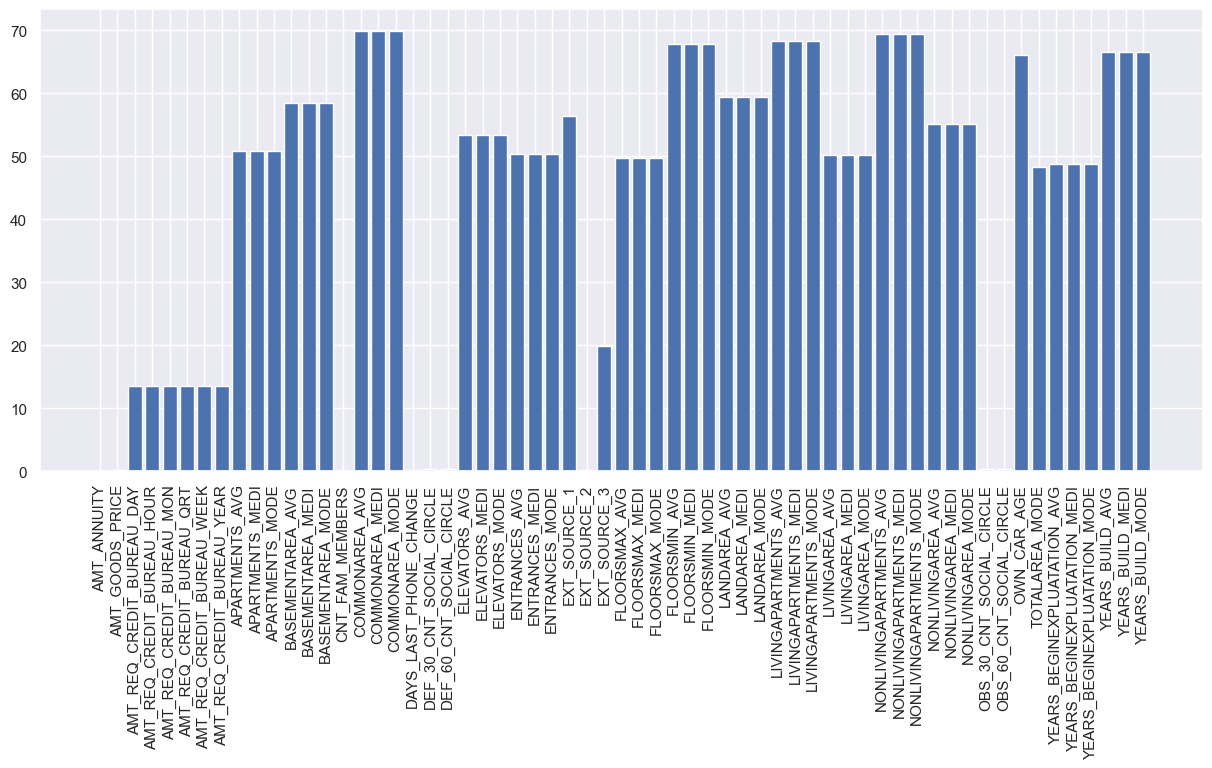

In [4]:
numerical_frame=main_data.loc[:, numerical_features]
plot_data=numerical_frame.isnull().sum()*100/numerical_frame.shape[0]
plot_data=plot_data[plot_data>0]
ax=plt.axes()
ax.bar(plot_data.index, plot_data.values)
ax.tick_params(axis='x', rotation=90)
ax.get_figure().set_size_inches(15, 6)

### Functions

In [5]:
def plot_hist_box(data, feature):
    fig, axes=plt.subplots(ncols=2)
    fig.set_size_inches(w=10, h=5)
    axes[0].boxplot(data[feature].dropna());
    axes[0].set_xticklabels([feature]);
    axes[1].hist(data[feature]);
    return axes

In [6]:
def plot_hist_default_pct(feature, dataframe, bins):
    df=dataframe.copy()
    df['%s_binned'%feature]=pd.qcut(df[feature], q=bins, precision=3, duplicates='drop')
    counts=df['%s_binned'%feature].value_counts()
    default_counts=df.loc[df['TARGET']==1, '%s_binned'%feature].value_counts()
    default_counts=default_counts*100/counts
    ax=plt.axes()
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    print(default_counts)


In [7]:
def calc_iqr(feature, data):
    q3=data[feature].quantile(0.75)
    q1=data[feature].quantile(0.25)
    iqr=q3-q1
    return q1, q3, iqr

In [8]:
def plot_kde_vs_target(feature, main_data=main_data):
    paid=main_data[main_data['TARGET']==0][feature]
    defaulted=main_data[main_data['TARGET']==1][feature]
    sns.kdeplot(paid, label='Paid', color='b')
    sns.kdeplot(defaulted, label='Defaulted', color='r')
    plt.legend()

In [9]:
def plot_all_numeric_kde():
    fig, axes=plt.subplots(numerical_features.shape[0])
    fig.set_size_inches(10, 4*numerical_features.shape[0])
    for i, feature in enumerate(numerical_features):
        q1, q3, iqr=calc_iqr(feature, main_data)
        plot_data=main_data.loc[(main_data[feature]>=q1-1.5*iqr) & (main_data[feature]<=q3+1.5*iqr), :]
        paid=plot_data[plot_data['TARGET']==0][feature]
        defaulted=plot_data[plot_data['TARGET']==1][feature]
        sns.kdeplot(paid, label='Paid', color='b', ax=axes[i])
        sns.kdeplot(defaulted, label='Defaulted', color='r', ax=axes[i])
        axes[i].legend()

In [10]:
def plot_pie_target(target_series, ax=None):
    if ax is None:
        ax=plt.axes()
    plot_data=target_series.value_counts()
    plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
    ax.pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
    return ax



In [11]:
def median_vs_target(feature, data):
    print('Median of %s with target=0 : %f'%(feature, data.loc[data['TARGET']==0, feature].median()))
    print('Median of %s with target=1 : %f'%(feature, data.loc[data['TARGET']==1, feature].median()))

In [12]:
# plot_all_numeric_kde()

### Important Numerical

In [13]:
important_kde=pd.Index(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE', 'DAYS_BIRTH',
                        'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION',
                        'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
                        'EXT_SOURCE_3'])
numerical_frame=numerical_frame[important_kde]
numerical_frame['TARGET']=main_data['TARGET']
numerical_frame['SK_ID_CURR']=main_data['SK_ID_CURR']

In [14]:
numerical_frame.isnull().sum()

AMT_ANNUITY                   12
AMT_CREDIT                     0
AMT_INCOME_TOTAL               0
AMT_GOODS_PRICE              278
DAYS_BIRTH                     0
DAYS_EMPLOYED                  0
DAYS_ID_PUBLISH                0
DAYS_REGISTRATION              0
DAYS_LAST_PHONE_CHANGE         1
EXT_SOURCE_1              173378
EXT_SOURCE_2                 660
EXT_SOURCE_3               60965
TARGET                         0
SK_ID_CURR                     0
dtype: int64

## AMT_CREDIT

In [15]:
numerical_frame['AMT_CREDIT'].isnull().sum()

0

In [16]:
numerical_frame['AMT_CREDIT'].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

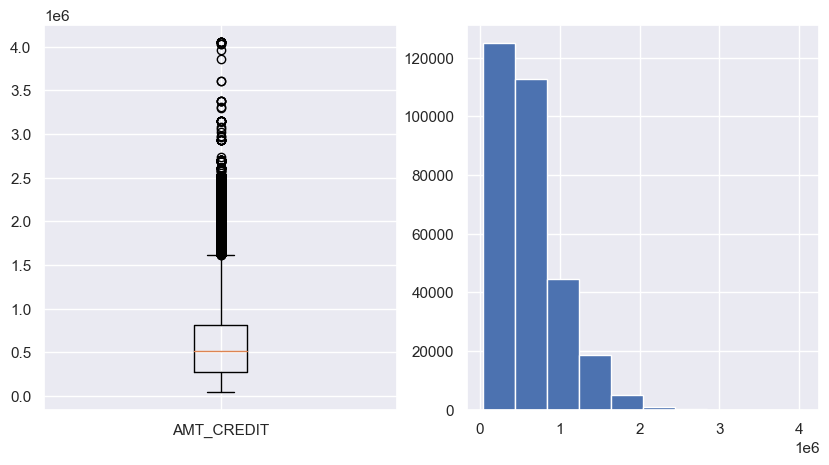

In [17]:
plot_hist_box(numerical_frame, 'AMT_CREDIT');

#### Marking outliers with a flag column

Number of outliers : 363


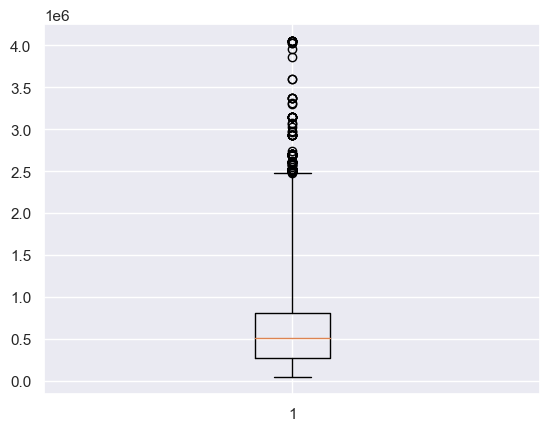

In [18]:
plt.boxplot(numerical_frame['AMT_CREDIT'], whis=3.1);
q1, q3, iqr=calc_iqr('AMT_CREDIT', numerical_frame)
numerical_frame['AMT_CREDIT_outlier']=0
numerical_frame.loc[numerical_frame['AMT_CREDIT']>q3+3.1*iqr, 'AMT_CREDIT_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_CREDIT_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_CREDIT_outlier']==1).sum()))

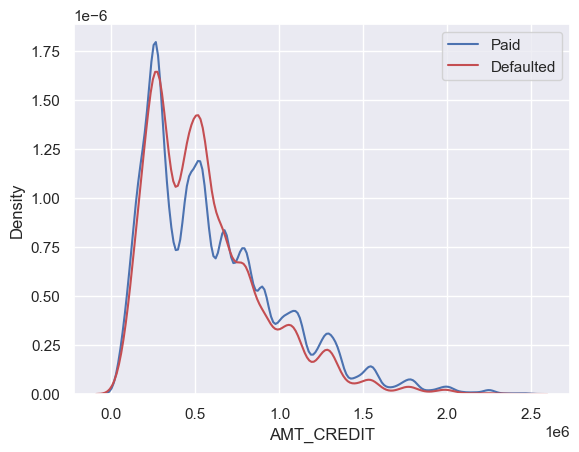

In [19]:
plot_kde_vs_target('AMT_CREDIT', good_frame)

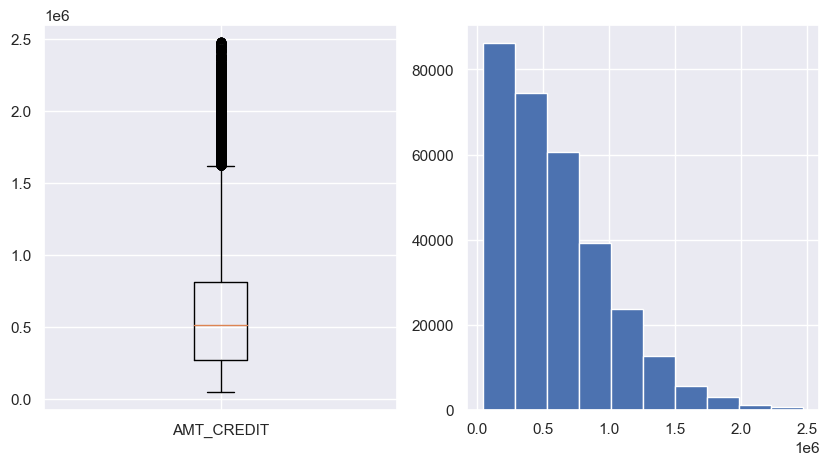

In [20]:
plot_hist_box(good_frame, 'AMT_CREDIT');

(44999.999, 188460.0]      6.801111
(188460.0, 266652.0]       7.678750
(266652.0, 337500.0]       8.721258
(337500.0, 454500.0]      10.305344
(454500.0, 545040.0]      10.153233
(545040.0, 679500.0]       9.081739
(679500.0, 855000.0]       7.741548
(855000.0, 1125000.0]      6.752499
(1125000.0, 2475000.0]     5.324342
Name: AMT_CREDIT_binned, dtype: float64


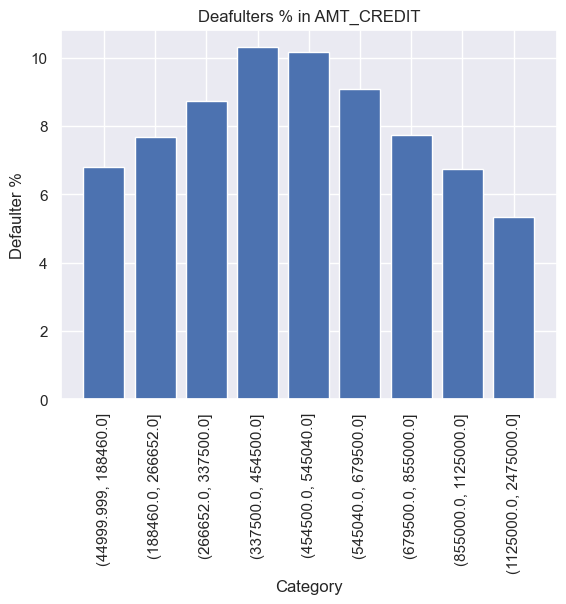

In [21]:
plot_hist_default_pct('AMT_CREDIT', good_frame, 9)

## AMT_INCOME_TOTAL

In [22]:
numerical_frame['AMT_INCOME_TOTAL'].isnull().sum()

0

In [23]:
numerical_frame['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

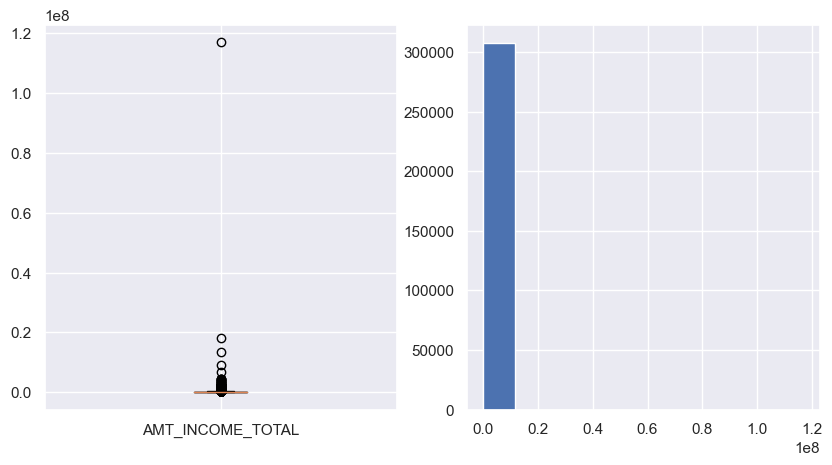

In [24]:
plot_hist_box(numerical_frame, 'AMT_INCOME_TOTAL')

Number of outliers : 738


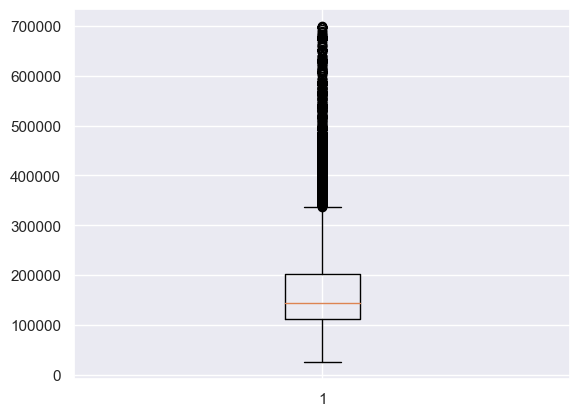

In [25]:
df=numerical_frame.loc[numerical_frame['AMT_INCOME_TOTAL']<0.7e6, :]
plt.boxplot(df['AMT_INCOME_TOTAL']);
numerical_frame['AMT_INCOME_TOTAL_outlier']=0
numerical_frame.loc[numerical_frame['AMT_INCOME_TOTAL']>=0.7e6, 'AMT_INCOME_TOTAL_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_INCOME_TOTAL_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_INCOME_TOTAL_outlier']==1).sum()))

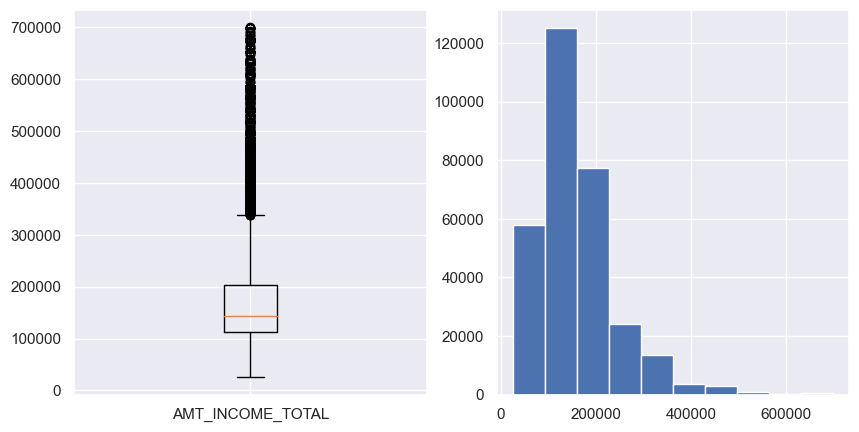

In [26]:
plot_hist_box(good_frame, 'AMT_INCOME_TOTAL');

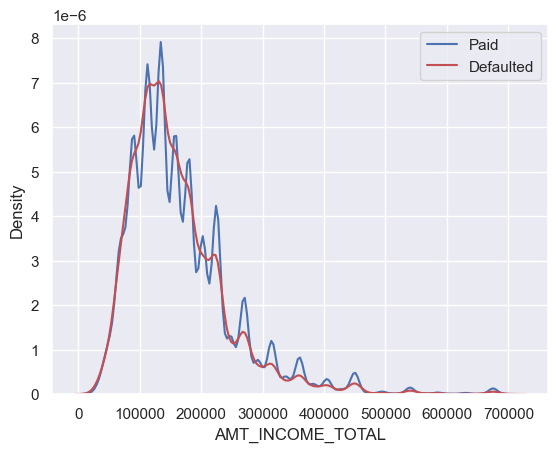

In [27]:
plot_kde_vs_target('AMT_INCOME_TOTAL', good_frame)

(25649.999, 85500.0]    8.184659
(85500.0, 108000.0]     8.269951
(108000.0, 117000.0]    8.773540
(117000.0, 135000.0]    8.469668
(135000.0, 157500.0]    8.745688
(157500.0, 180000.0]    8.374066
(180000.0, 216000.0]    8.018968
(216000.0, 270000.0]    7.312805
(270000.0, 699750.0]    6.176437
Name: AMT_INCOME_TOTAL_binned, dtype: float64


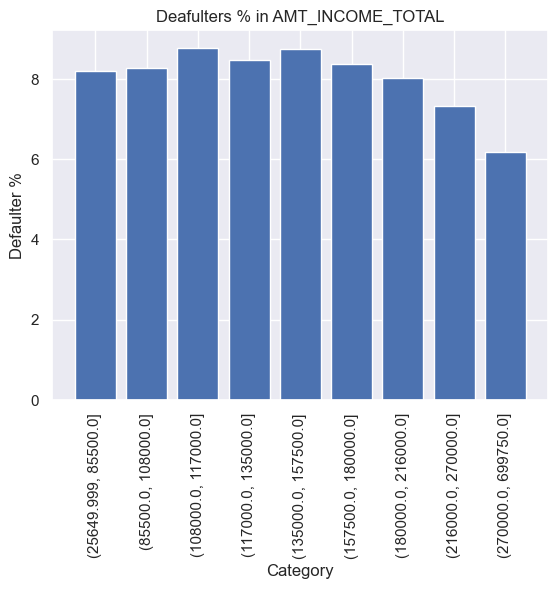

In [28]:
plot_hist_default_pct('AMT_INCOME_TOTAL', good_frame, 9)

## AMT_ANNUITY

In [29]:
numerical_frame['AMT_ANNUITY'].isnull().sum()

12

In [30]:
numerical_frame['AMT_ANNUITY'].describe()

count    307499.000000
mean      27108.573909
std       14493.737315
min        1615.500000
25%       16524.000000
50%       24903.000000
75%       34596.000000
max      258025.500000
Name: AMT_ANNUITY, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

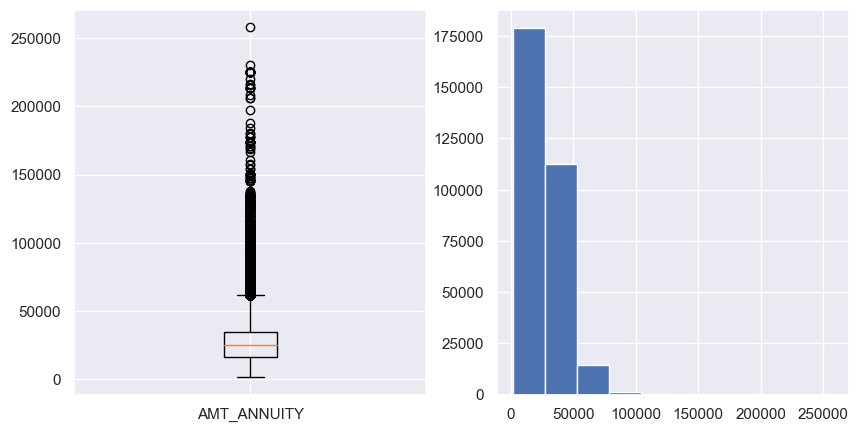

In [31]:
plot_hist_box(numerical_frame, 'AMT_ANNUITY')

Number of outliers : 81


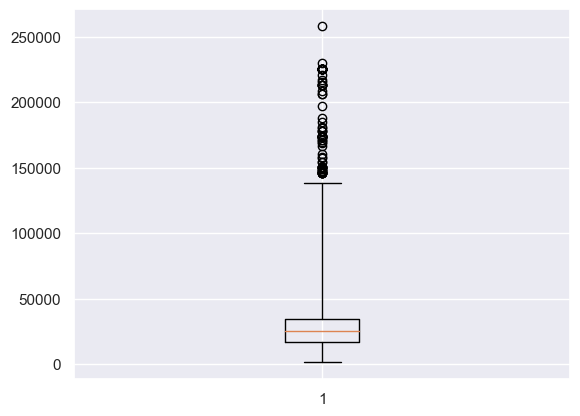

In [32]:
plt.boxplot(numerical_frame['AMT_ANNUITY'].dropna(), whis=6);
q1, q3, iqr=calc_iqr('AMT_ANNUITY', numerical_frame)
numerical_frame['AMT_ANNUITY_outlier']=0
numerical_frame.loc[numerical_frame['AMT_ANNUITY']>q3+6*iqr, 'AMT_ANNUITY_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_ANNUITY_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_ANNUITY_outlier']==1).sum()))

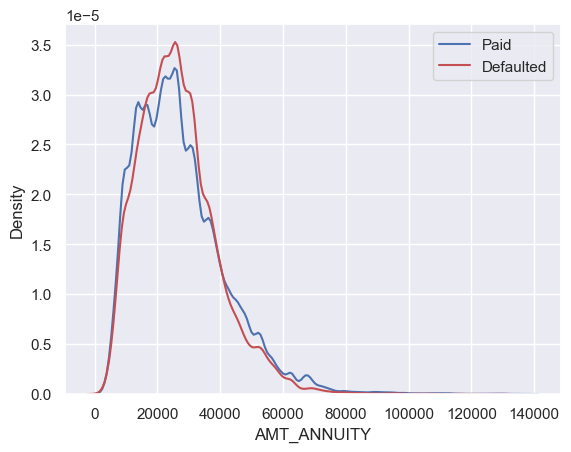

In [33]:
plot_kde_vs_target('AMT_ANNUITY', good_frame)

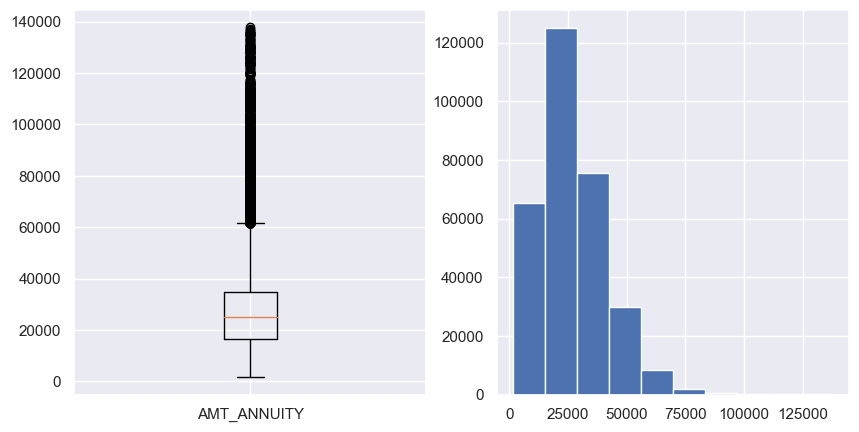

In [34]:
plot_hist_box(good_frame, 'AMT_ANNUITY');

(1615.499, 11502.0]    6.943591
(11502.0, 15705.0]     7.173379
(15705.0, 19548.0]     8.701763
(19548.0, 23107.5]     8.811613
(23107.5, 26473.5]     8.239998
(26473.5, 30717.0]     9.772290
(30717.0, 36229.5]     9.306161
(36229.5, 44775.0]     7.825171
(44775.0, 137844.0]    5.896820
Name: AMT_ANNUITY_binned, dtype: float64


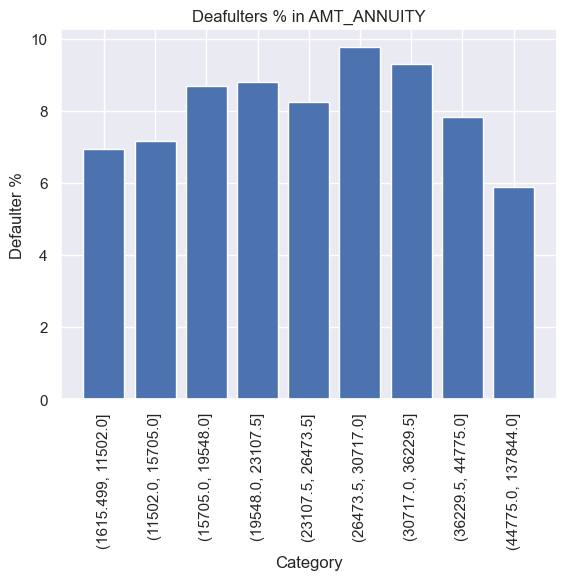

In [35]:
plot_hist_default_pct('AMT_ANNUITY', good_frame, 9)

## AMT_GOODS_PRICE

In [36]:
numerical_frame['AMT_GOODS_PRICE'].isnull().sum()

278

In [37]:
numerical_frame['AMT_GOODS_PRICE'].describe()

count    3.072330e+05
mean     5.383962e+05
std      3.694465e+05
min      4.050000e+04
25%      2.385000e+05
50%      4.500000e+05
75%      6.795000e+05
max      4.050000e+06
Name: AMT_GOODS_PRICE, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

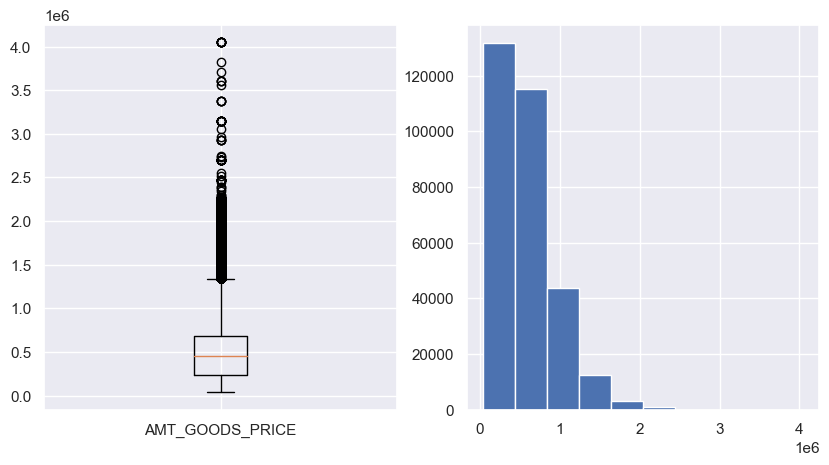

In [38]:
plot_hist_box(numerical_frame, 'AMT_GOODS_PRICE')

Number of outliers : 69


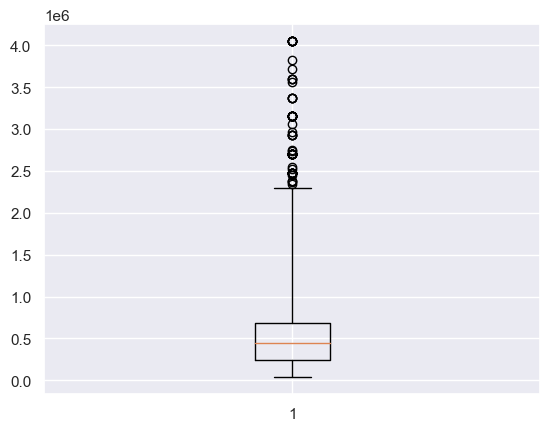

In [39]:
plt.boxplot(numerical_frame['AMT_GOODS_PRICE'].dropna(), whis=3.7);
q1, q3, iqr=calc_iqr('AMT_GOODS_PRICE', numerical_frame)
numerical_frame['AMT_GOODS_PRICE_outlier']=0
numerical_frame.loc[numerical_frame['AMT_GOODS_PRICE']>q3+3.7*iqr, 'AMT_GOODS_PRICE_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['AMT_GOODS_PRICE_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['AMT_GOODS_PRICE_outlier']==1).sum()))

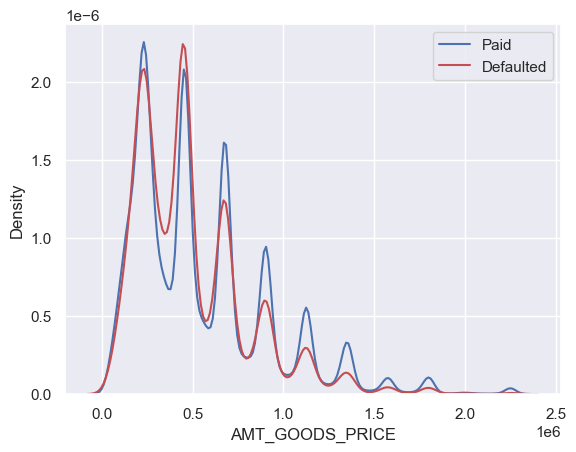

In [40]:
plot_kde_vs_target('AMT_GOODS_PRICE', good_frame)

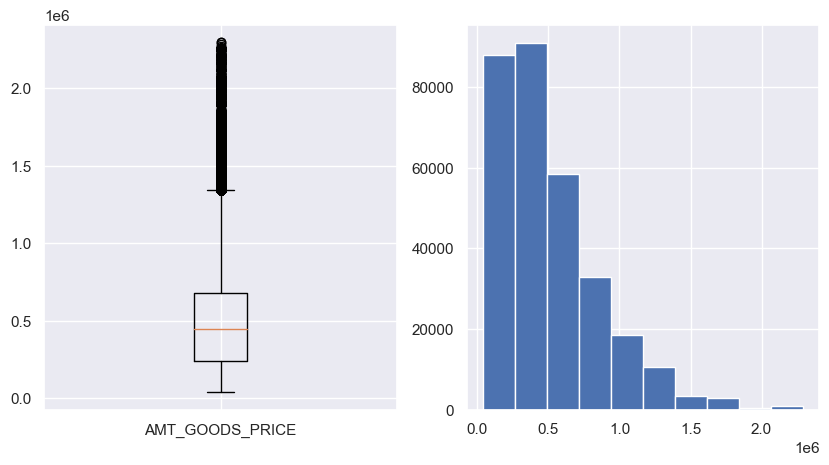

In [41]:
plot_hist_box(good_frame, 'AMT_GOODS_PRICE');

(40499.999, 180000.0]     7.286496
(180000.0, 225000.0]      8.908352
(225000.0, 292500.0]      7.907479
(292500.0, 450000.0]     12.225508
(450000.0, 463500.0]      5.750231
(463500.0, 675000.0]      8.231946
(675000.0, 720000.0]      4.954737
(720000.0, 994500.0]      6.633725
(994500.0, 2295000.0]     5.040441
Name: AMT_GOODS_PRICE_binned, dtype: float64


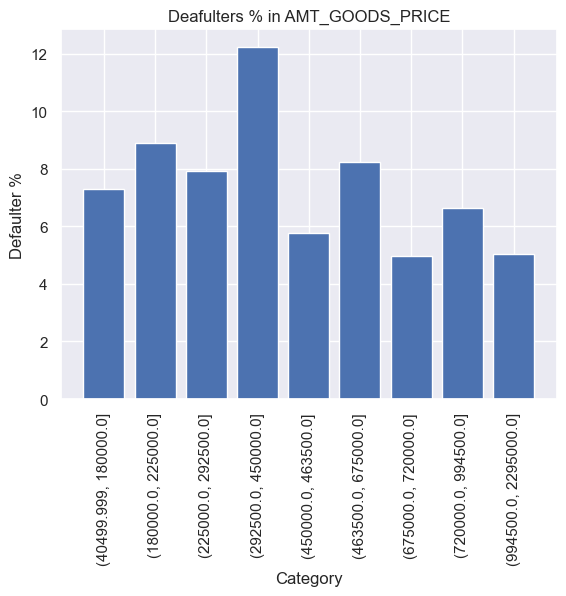

In [42]:
plot_hist_default_pct('AMT_GOODS_PRICE', good_frame, 9)

## DAYS_BIRTH

In [43]:
numerical_frame['DAYS_BIRTH'].isnull().sum()

0

In [44]:
numerical_frame['DAYS_BIRTH'].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

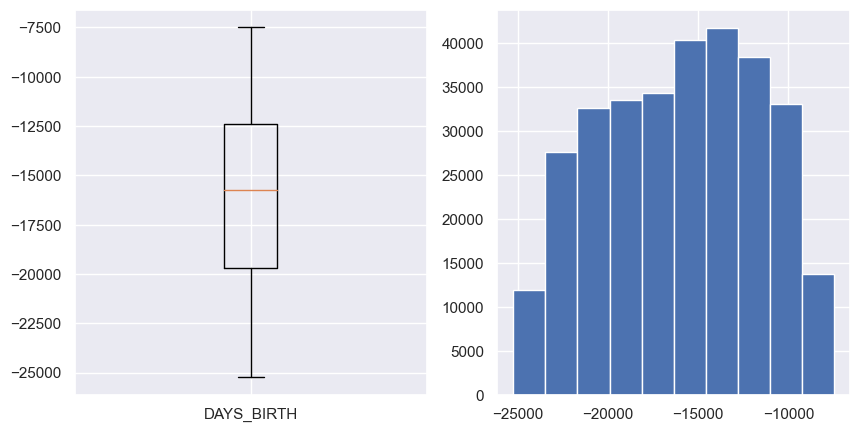

In [45]:
plot_hist_box(numerical_frame, 'DAYS_BIRTH')

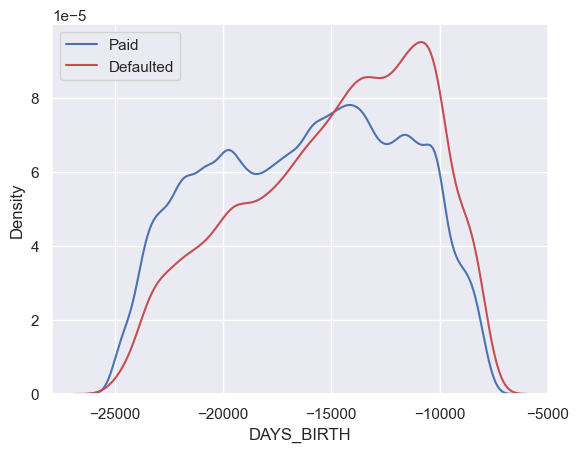

In [46]:
plot_kde_vs_target('DAYS_BIRTH', numerical_frame)

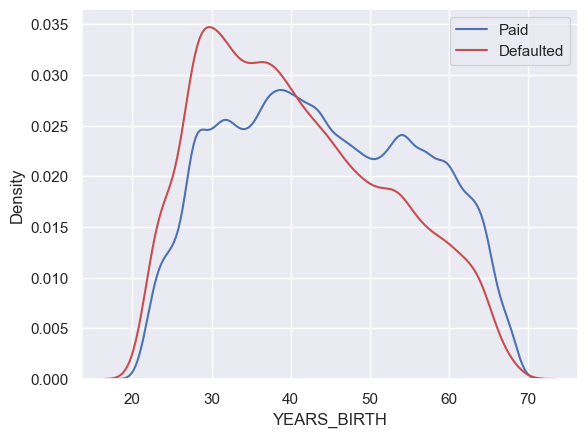

In [47]:
numerical_frame['YEARS_BIRTH']=numerical_frame['DAYS_BIRTH']/-365
plot_kde_vs_target('YEARS_BIRTH', numerical_frame)

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

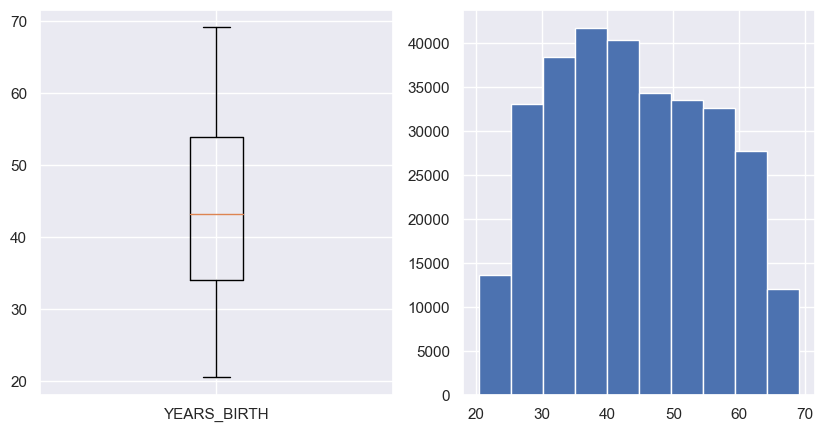

In [48]:
plot_hist_box(numerical_frame, 'YEARS_BIRTH')

(20.517, 28.594]    11.537111
(28.594, 32.899]    10.686487
(32.899, 37.195]     9.724336
(37.195, 41.09]      8.406976
(41.09, 45.31]       7.802664
(45.31, 50.173]      7.422469
(50.173, 55.047]     6.633489
(55.047, 60.225]     5.478971
(60.225, 69.121]     4.961799
Name: YEARS_BIRTH_binned, dtype: float64


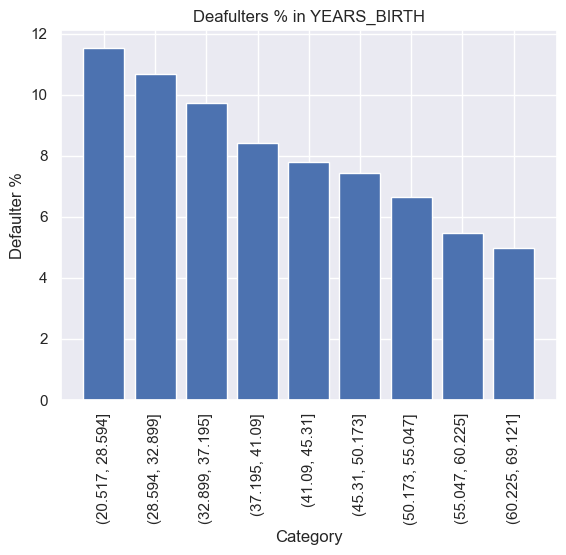

In [49]:
plot_hist_default_pct('YEARS_BIRTH', numerical_frame, 9)

## DAYS_ID_PUBLISH

In [50]:
numerical_frame['DAYS_ID_PUBLISH'].isnull().sum()

0

In [51]:
numerical_frame['DAYS_ID_PUBLISH'].describe()

count    307511.000000
mean      -2994.202373
std        1509.450419
min       -7197.000000
25%       -4299.000000
50%       -3254.000000
75%       -1720.000000
max           0.000000
Name: DAYS_ID_PUBLISH, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

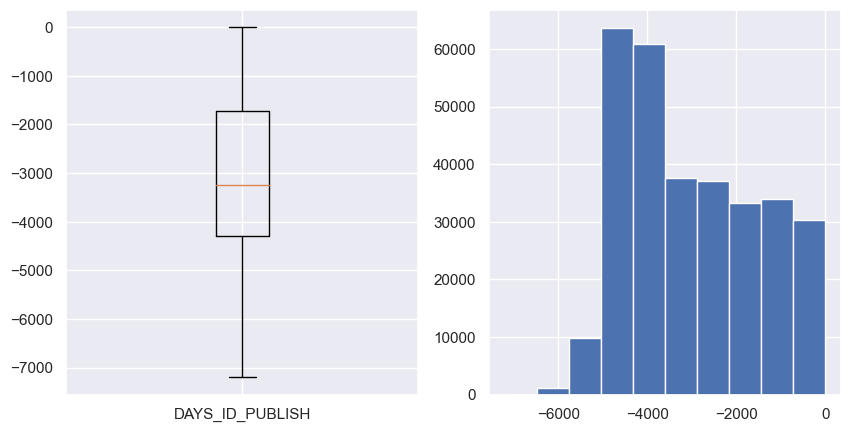

In [52]:
plot_hist_box(numerical_frame, 'DAYS_ID_PUBLISH')

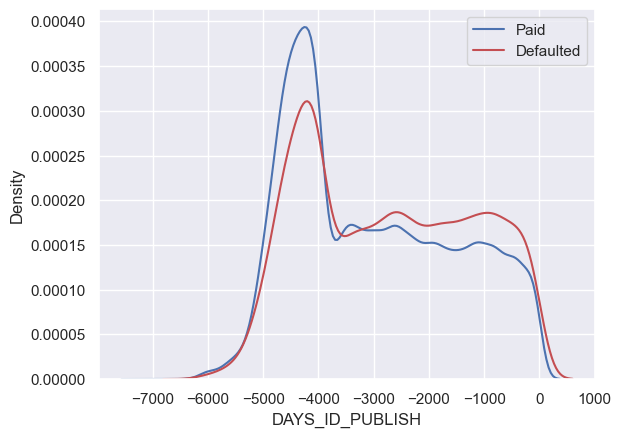

In [53]:

plot_kde_vs_target('DAYS_ID_PUBLISH', numerical_frame)

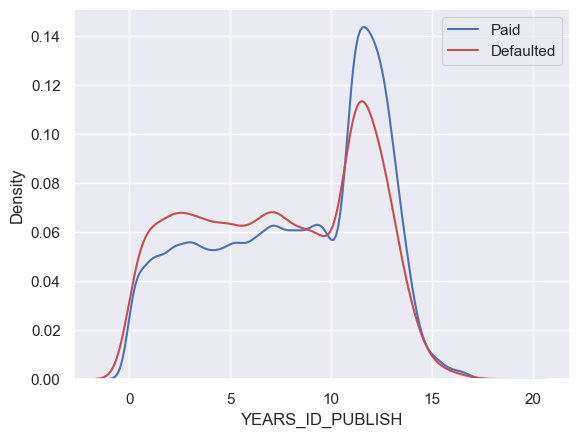

In [54]:
numerical_frame['YEARS_ID_PUBLISH']=numerical_frame['DAYS_ID_PUBLISH']/-365
plot_kde_vs_target('YEARS_ID_PUBLISH', numerical_frame)

(-0.001, 2.192]     10.169541
(2.192, 4.192]       9.734176
(4.192, 6.197]       9.210642
(6.197, 8.0]         8.753588
(8.0, 9.789]         7.963488
(9.789, 11.205]      7.880824
(11.205, 11.978]     6.769168
(11.978, 12.833]     6.095099
(12.833, 19.718]     6.074712
Name: YEARS_ID_PUBLISH_binned, dtype: float64


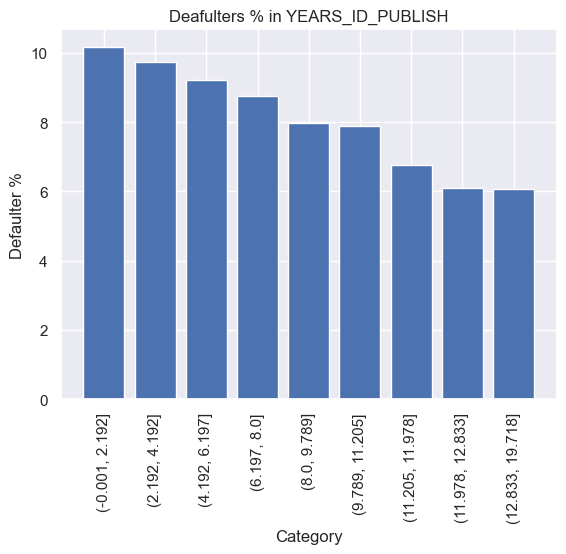

In [55]:
plot_hist_default_pct('YEARS_ID_PUBLISH', numerical_frame, 9)

## DAYS_REGISTRATION

In [56]:
numerical_frame['DAYS_REGISTRATION'].isnull().sum()

0

In [57]:
numerical_frame['DAYS_REGISTRATION'].describe()

count    307511.000000
mean      -4986.120328
std        3522.886321
min      -24672.000000
25%       -7479.500000
50%       -4504.000000
75%       -2010.000000
max           0.000000
Name: DAYS_REGISTRATION, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

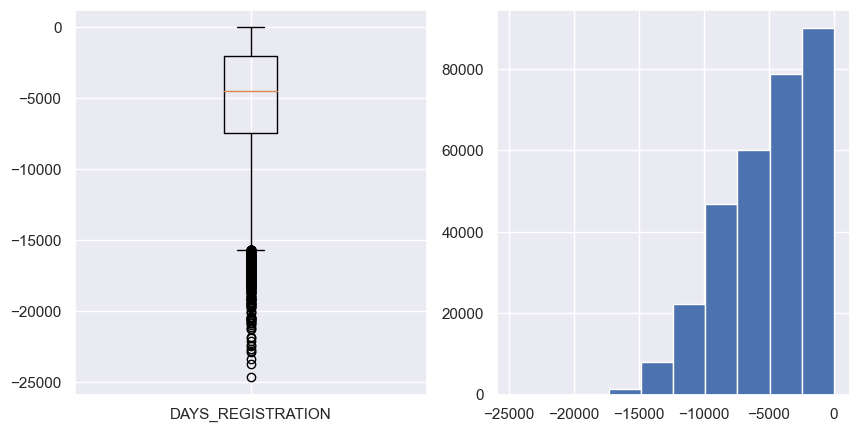

In [58]:
plot_hist_box(numerical_frame, 'DAYS_REGISTRATION')

Number of outliers : 30


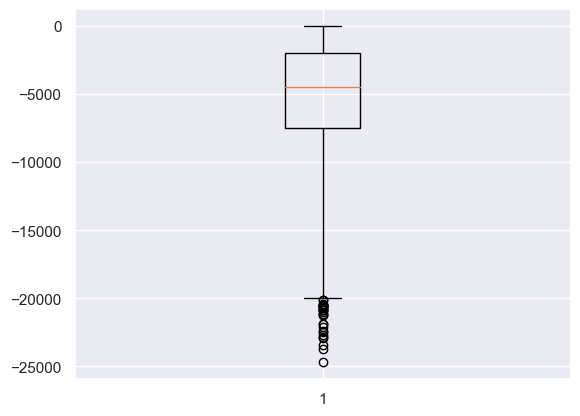

In [59]:
plt.boxplot(numerical_frame['DAYS_REGISTRATION'], whis=2.3);
numerical_frame['YEARS_REGISTRATION']=numerical_frame['DAYS_REGISTRATION']/-365
q1, q3, iqr=calc_iqr('DAYS_REGISTRATION', numerical_frame)
numerical_frame['DAYS_REGISTRATION_outlier']=0
numerical_frame.loc[numerical_frame['DAYS_REGISTRATION']<q1-2.3*iqr, 'DAYS_REGISTRATION_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_REGISTRATION_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_REGISTRATION_outlier']==1).sum()))

In [60]:
# fig, axes=plt.subplots(ncols=2)
# fig.set_size_inches(w=10, h=5)
# plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_REGISTRATION']<-15500, 'TARGET'], ax=axes[1])
# axes[1].set_title("Defaulters in Outliers");
# plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_REGISTRATION']>=-15500, 'TARGET'], ax=axes[0])
# axes[0].set_title("Defaulters in Non_Outliers");


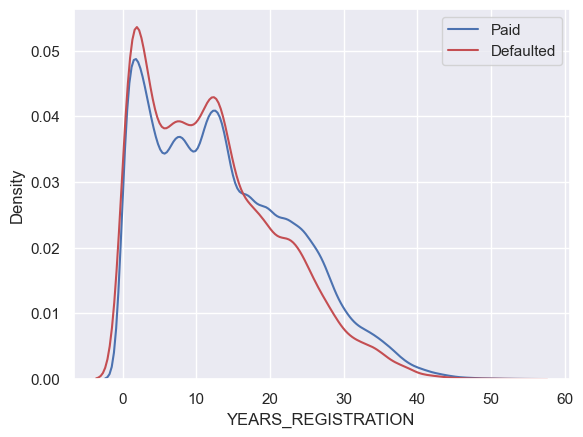

In [61]:
plot_kde_vs_target('YEARS_REGISTRATION', good_frame)

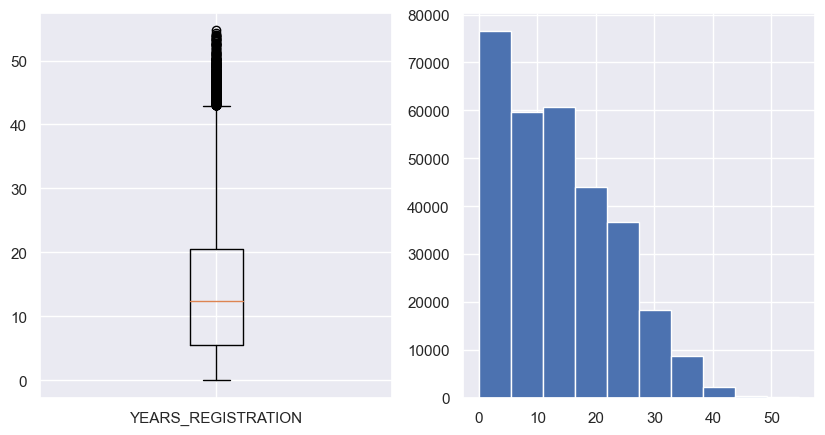

In [62]:
plot_hist_box(good_frame, 'YEARS_REGISTRATION');

(-0.001, 2.107]     9.656947
(2.107, 4.699]      8.869056
(4.699, 7.838]      8.647509
(7.838, 10.978]     8.747329
(10.978, 13.671]    8.634861
(13.671, 17.307]    8.198354
(17.307, 21.655]    7.336066
(21.655, 26.611]    6.896451
(26.611, 54.753]    5.671703
Name: YEARS_REGISTRATION_binned, dtype: float64


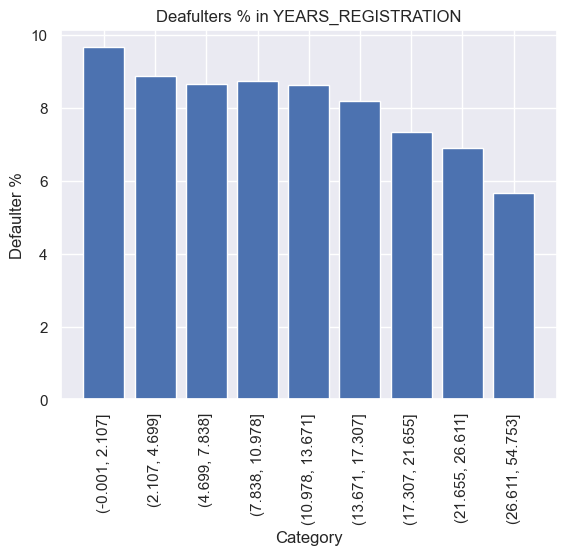

In [63]:
plot_hist_default_pct('YEARS_REGISTRATION', good_frame, 9)

## DAYS_EMPLOYED

In [64]:
numerical_frame['DAYS_EMPLOYED'].isnull().sum()

0

In [65]:
numerical_frame['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

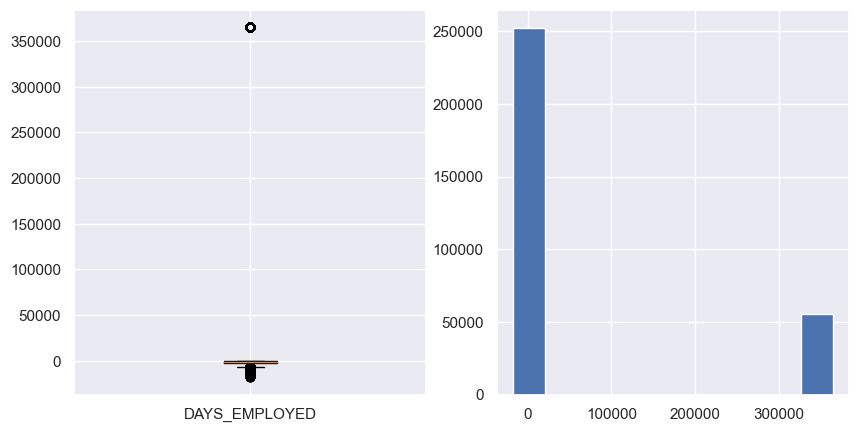

In [66]:
plot_hist_box(numerical_frame, 'DAYS_EMPLOYED');

In [67]:
numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']>0, ['DAYS_EMPLOYED', 'TARGET']].value_counts()

DAYS_EMPLOYED  TARGET
365243         0         52384
               1          2990
dtype: int64

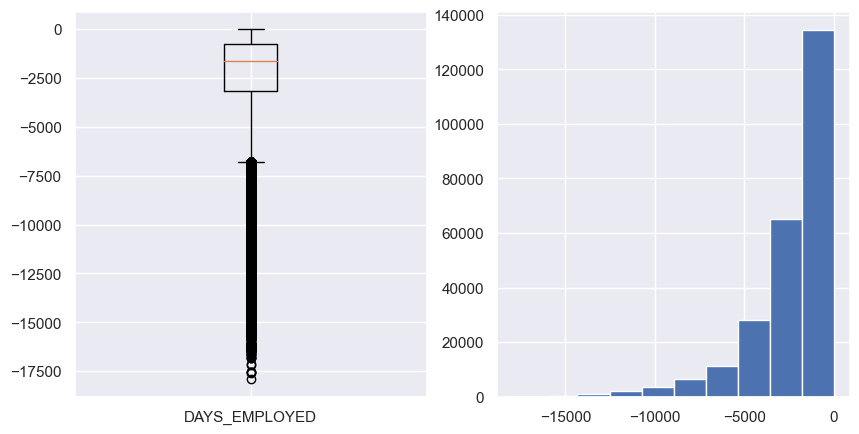

In [68]:
numerical_frame.replace({'DAYS_EMPLOYED': {365243: np.nan}}, inplace=True)
plot_hist_box(numerical_frame, 'DAYS_EMPLOYED');

Number of outliers : 58


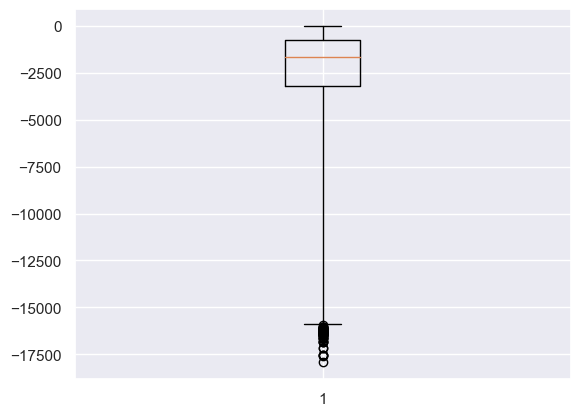

In [69]:
plt.boxplot(numerical_frame['DAYS_EMPLOYED'].dropna(), whis=5.3);
numerical_frame['YEARS_EMPLOYED']=numerical_frame['DAYS_EMPLOYED']/-365
q1, q3, iqr=calc_iqr('DAYS_EMPLOYED', numerical_frame)
numerical_frame['DAYS_EMPLOYED_outlier']=0
numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']<q1-5.3*iqr, 'DAYS_EMPLOYED_outlier']=1
good_frame=numerical_frame.loc[numerical_frame['DAYS_EMPLOYED_outlier']==0, :]
print('Number of outliers : %d'%((numerical_frame['DAYS_EMPLOYED_outlier']==1).sum()))

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

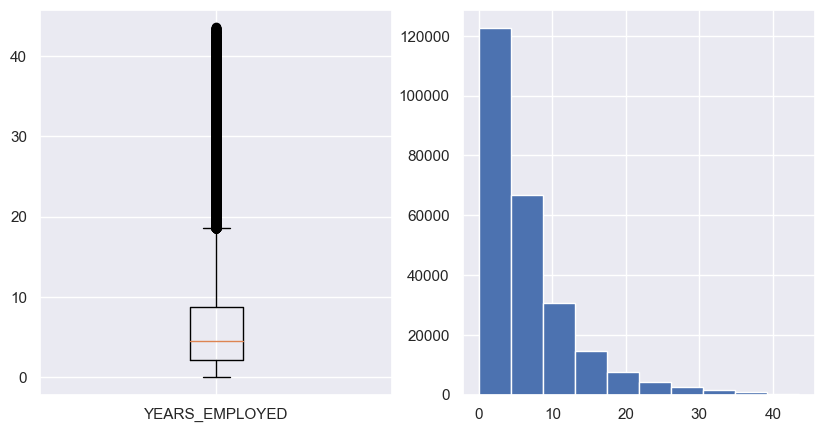

In [70]:
plot_hist_box(good_frame, 'YEARS_EMPLOYED')

In [71]:
# fig, axes=plt.subplots(ncols=2)
# fig.set_size_inches(w=10, h=5)
# plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']>0, 'TARGET'], ax=axes[1])
# axes[1].set_title("Defaulters in Outliers");
# plot_pie_target(numerical_frame.loc[numerical_frame['DAYS_EMPLOYED']<=0, 'TARGET'], ax=axes[0])
# axes[0].set_title("Defaulters in Non_Outliers");


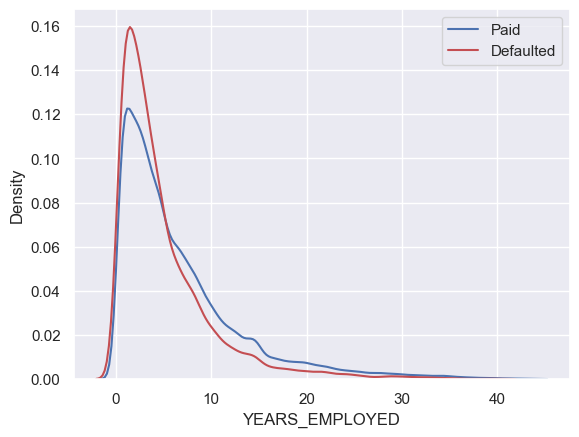

In [72]:

plot_kde_vs_target('YEARS_EMPLOYED', good_frame);

(-0.001, 1.003]     10.975697
(1.003, 1.879]      11.456996
(1.879, 2.808]      10.972729
(2.808, 3.89]       10.115246
(3.89, 5.205]        9.100975
(5.205, 7.033]       7.769800
(7.033, 9.422]       7.011782
(9.422, 13.997]      5.877312
(13.997, 43.592]     4.668191
Name: YEARS_EMPLOYED_binned, dtype: float64


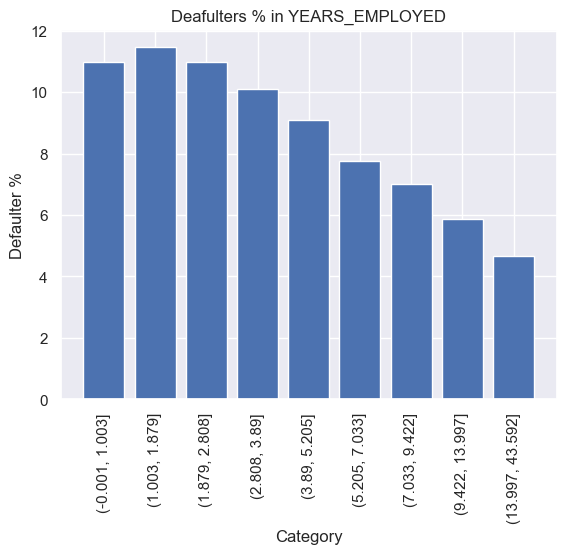

In [73]:
plot_hist_default_pct('YEARS_EMPLOYED', good_frame, 9)

## DAYS_LAST_PHONE_CHANGE

In [74]:
numerical_frame['DAYS_LAST_PHONE_CHANGE'].isnull().sum()

1

In [75]:
numerical_frame['DAYS_LAST_PHONE_CHANGE'].describe()

count    307510.000000
mean       -962.858788
std         826.808487
min       -4292.000000
25%       -1570.000000
50%        -757.000000
75%        -274.000000
max           0.000000
Name: DAYS_LAST_PHONE_CHANGE, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

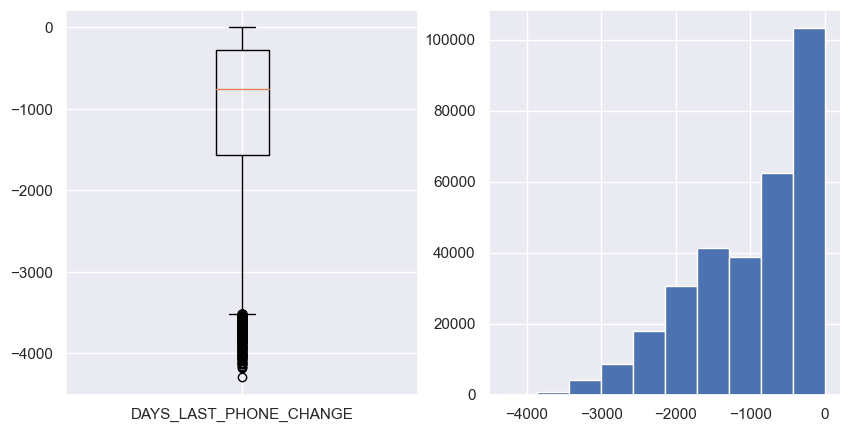

In [76]:
plot_hist_box(numerical_frame, 'DAYS_LAST_PHONE_CHANGE')

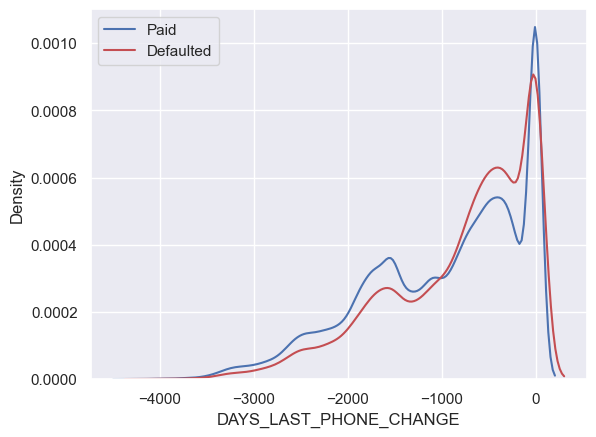

In [77]:
plot_kde_vs_target('DAYS_LAST_PHONE_CHANGE', numerical_frame)

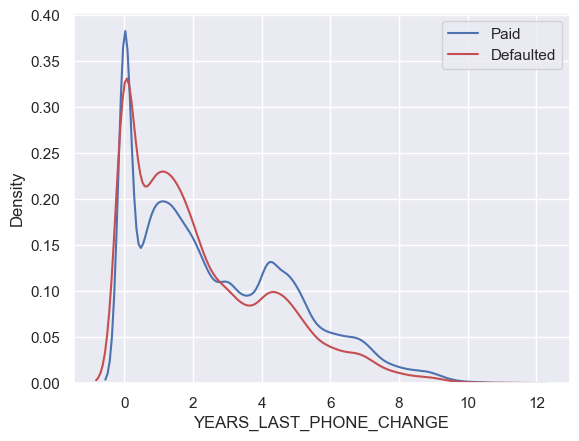

In [78]:
numerical_frame['YEARS_LAST_PHONE_CHANGE']=numerical_frame['DAYS_LAST_PHONE_CHANGE']/-365
plot_kde_vs_target('YEARS_LAST_PHONE_CHANGE', numerical_frame)

(-0.001, 0.592]    9.447335
(0.592, 1.164]     9.585872
(1.164, 1.74]      9.466710
(1.74, 2.488]      8.822155
(2.488, 3.548]     7.624711
(3.548, 4.523]     6.531868
(4.523, 5.712]     6.268840
(5.712, 11.759]    5.456674
Name: YEARS_LAST_PHONE_CHANGE_binned, dtype: float64


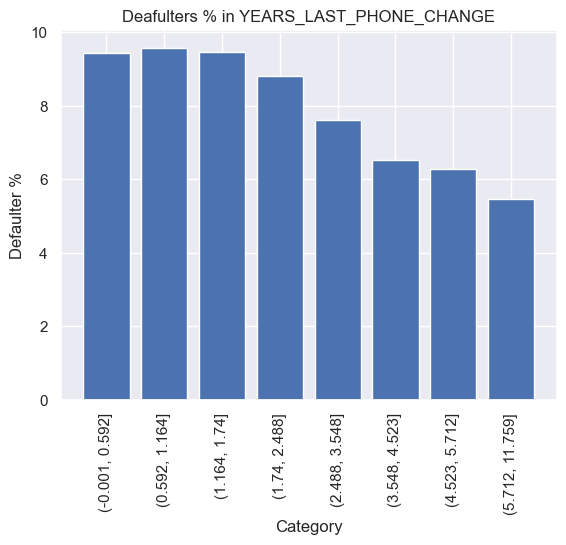

In [79]:
plot_hist_default_pct('YEARS_LAST_PHONE_CHANGE', numerical_frame, 9)

## EXT_SOURCE_1

In [80]:
numerical_frame['EXT_SOURCE_1'].isnull().sum()

173378

In [81]:
numerical_frame['EXT_SOURCE_1'].describe()

count    134133.000000
mean          0.502130
std           0.211062
min           0.014568
25%           0.334007
50%           0.505998
75%           0.675053
max           0.962693
Name: EXT_SOURCE_1, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

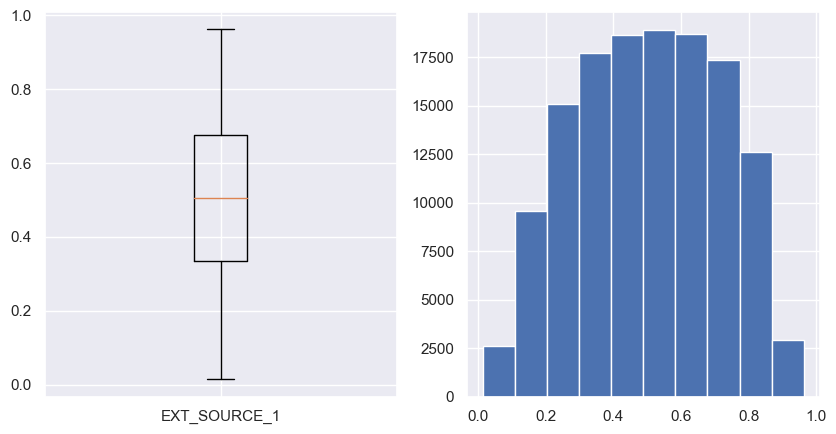

In [82]:
plot_hist_box(numerical_frame, 'EXT_SOURCE_1')

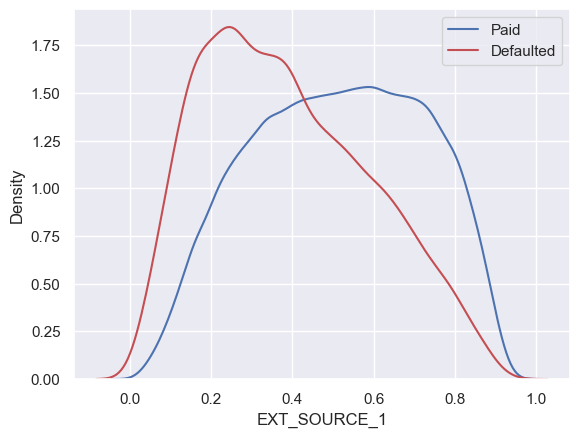

In [83]:
plot_kde_vs_target('EXT_SOURCE_1', numerical_frame)

(0.013600000000000001, 0.223]    16.968599
(0.223, 0.313]                   11.225174
(0.313, 0.392]                    9.078709
(0.392, 0.468]                    7.440955
(0.468, 0.544]                    6.401396
(0.544, 0.618]                    5.414654
(0.618, 0.694]                    4.737301
(0.694, 0.777]                    3.502415
(0.777, 0.963]                    2.690553
Name: EXT_SOURCE_1_binned, dtype: float64


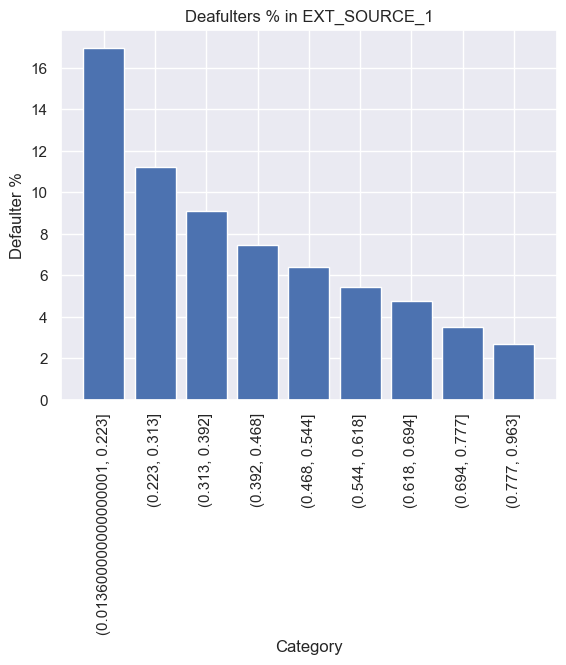

In [84]:
plot_hist_default_pct('EXT_SOURCE_1', numerical_frame, 9)

#### Looking NAN values

In [85]:
numerical_frame.loc[numerical_frame['EXT_SOURCE_1'].isnull(), 'TARGET'].value_counts()

0    158607
1     14771
Name: TARGET, dtype: int64

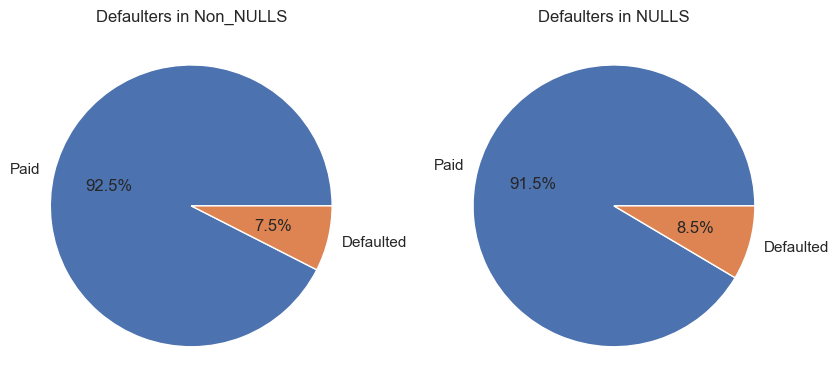

In [86]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_1'].isnull(), 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in NULLS");
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_1'].notnull(), 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_NULLS");


## EXT_SOURCE_2

In [87]:
numerical_frame['EXT_SOURCE_2'].isnull().sum()

660

In [88]:
numerical_frame['EXT_SOURCE_2'].describe()

count    3.068510e+05
mean     5.143927e-01
std      1.910602e-01
min      8.173617e-08
25%      3.924574e-01
50%      5.659614e-01
75%      6.636171e-01
max      8.549997e-01
Name: EXT_SOURCE_2, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

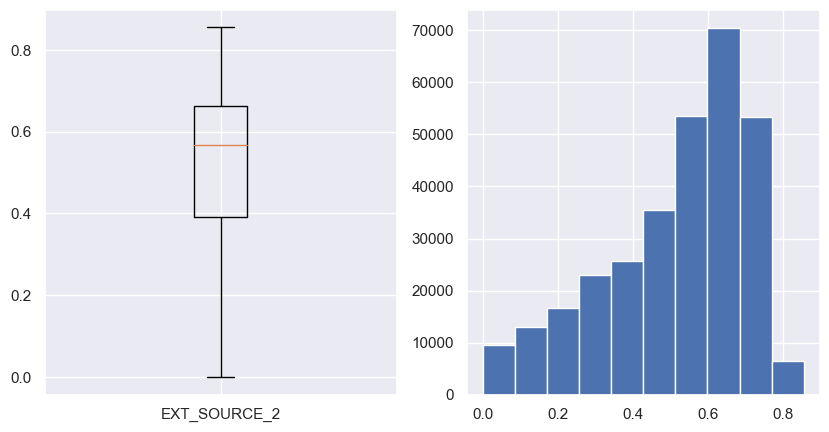

In [89]:
plot_hist_box(numerical_frame, 'EXT_SOURCE_2')

Median of EXT_SOURCE_3 with target=0 : 0.546023
Median of EXT_SOURCE_3 with target=1 : 0.379100


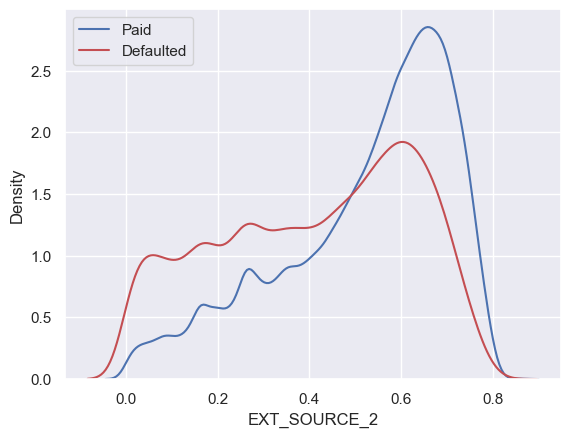

In [90]:
plot_kde_vs_target('EXT_SOURCE_2', numerical_frame)
median_vs_target('EXT_SOURCE_3', numerical_frame)

(-0.0009999183, 0.234]    17.855991
(0.234, 0.362]            11.614947
(0.362, 0.467]             9.555093
(0.467, 0.538]             7.866948
(0.538, 0.59]              7.047541
(0.59, 0.634]              6.168603
(0.634, 0.674]             5.167913
(0.674, 0.717]             4.338007
(0.717, 0.855]             3.044435
Name: EXT_SOURCE_2_binned, dtype: float64


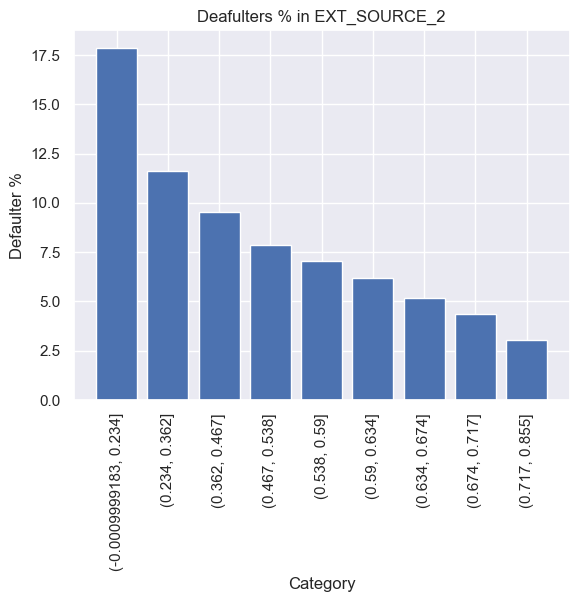

In [91]:
plot_hist_default_pct('EXT_SOURCE_2', numerical_frame, 9)

#### Looking NAN values

In [92]:
numerical_frame.loc[numerical_frame['EXT_SOURCE_2'].isnull(), 'TARGET'].value_counts()

0    608
1     52
Name: TARGET, dtype: int64

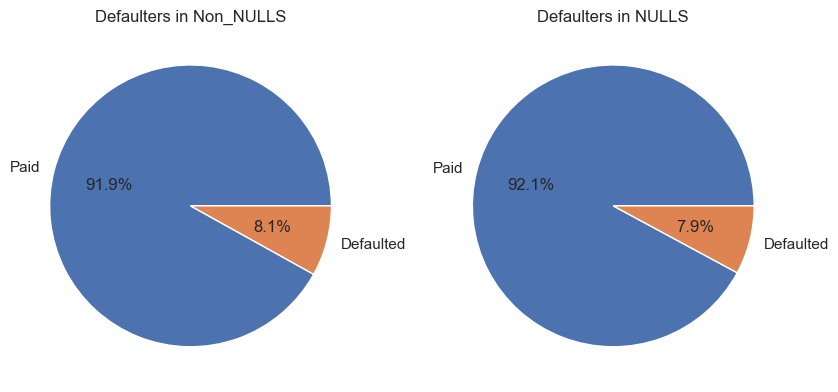

In [93]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_2'].isnull(), 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in NULLS");
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_2'].notnull(), 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_NULLS");


## EXT_SOURCE_3

In [94]:
numerical_frame['EXT_SOURCE_3'].isnull().sum()

60965

In [95]:
numerical_frame['EXT_SOURCE_3'].describe()

count    246546.000000
mean          0.510853
std           0.194844
min           0.000527
25%           0.370650
50%           0.535276
75%           0.669057
max           0.896010
Name: EXT_SOURCE_3, dtype: float64

array([<AxesSubplot: >, <AxesSubplot: >], dtype=object)

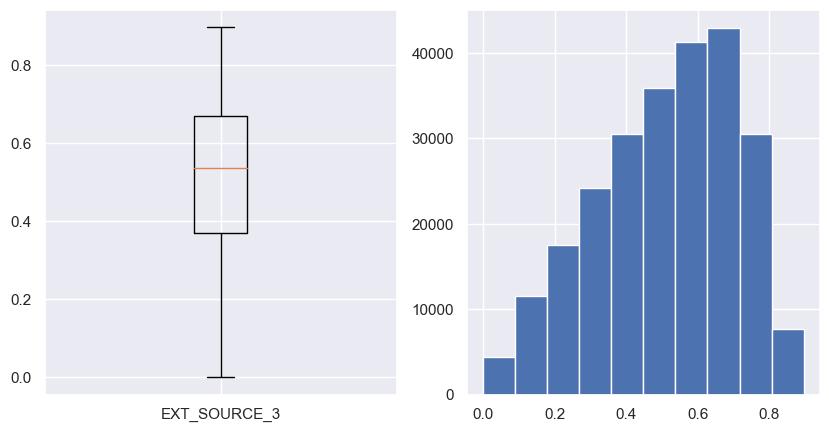

In [96]:
plot_hist_box(numerical_frame, 'EXT_SOURCE_3')

Median of EXT_SOURCE_3 with target=0 : 0.546023
Median of EXT_SOURCE_3 with target=1 : 0.379100


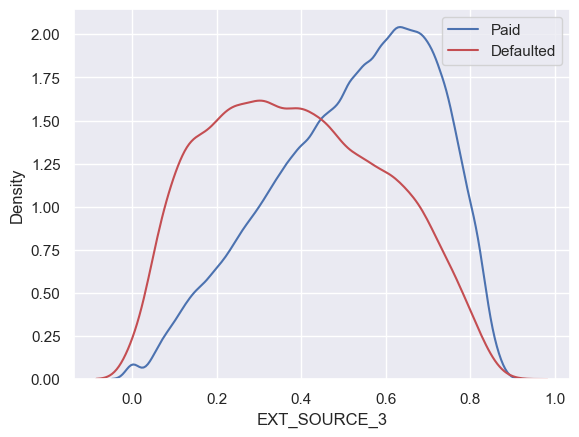

In [97]:
plot_kde_vs_target('EXT_SOURCE_3', numerical_frame)
median_vs_target('EXT_SOURCE_3', numerical_frame)

(-0.000473, 0.241]    19.504925
(0.241, 0.349]        11.999276
(0.349, 0.431]         9.081228
(0.431, 0.503]         7.340862
(0.503, 0.566]         5.775487
(0.566, 0.626]         4.846578
(0.626, 0.682]         4.322928
(0.682, 0.744]         3.695388
(0.744, 0.896]         3.219559
Name: EXT_SOURCE_3_binned, dtype: float64


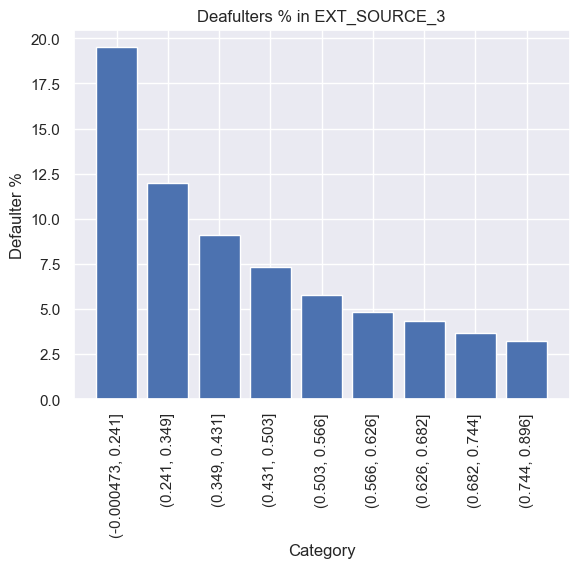

In [98]:
plot_hist_default_pct('EXT_SOURCE_3', numerical_frame, 9)

In [99]:
numerical_frame.loc[numerical_frame['EXT_SOURCE_3'].isnull(), 'TARGET'].value_counts()

0    55288
1     5677
Name: TARGET, dtype: int64

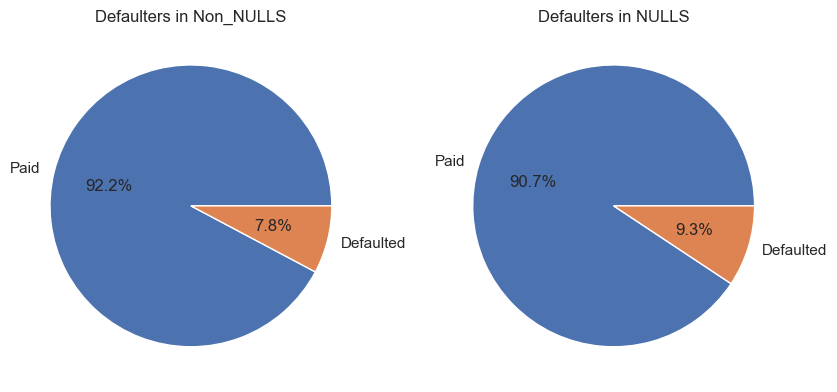

In [100]:
fig, axes=plt.subplots(ncols=2)
fig.set_size_inches(w=10, h=5)
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_3'].isnull(), 'TARGET'], ax=axes[1])
axes[1].set_title("Defaulters in NULLS");
plot_pie_target(numerical_frame.loc[numerical_frame['EXT_SOURCE_3'].notnull(), 'TARGET'], ax=axes[0])
axes[0].set_title("Defaulters in Non_NULLS");


# Categorical Features

In [101]:
categorical_frame=main_data[categorical_features].copy()
categorical_frame['TARGET']=main_data['TARGET']
categorical_frame['SK_ID_CURR']=main_data['SK_ID_CURR']
print(categorical_frame.isnull().sum())
del df
del good_frame
del plot_data

gc.collect()

CODE_GENDER                        0
EMERGENCYSTATE_MODE           145755
FLAG_OWN_CAR                       0
FLAG_OWN_REALTY                    0
FONDKAPREMONT_MODE            210295
HOUSETYPE_MODE                154297
NAME_CONTRACT_TYPE                 0
NAME_EDUCATION_TYPE                0
NAME_FAMILY_STATUS                 0
NAME_HOUSING_TYPE                  0
NAME_INCOME_TYPE                   0
NAME_TYPE_SUITE                 1292
OCCUPATION_TYPE                96391
ORGANIZATION_TYPE                  0
WALLSMATERIAL_MODE            156341
WEEKDAY_APPR_PROCESS_START         0
TARGET                             0
SK_ID_CURR                         0
dtype: int64


29006

#### Functions

In [102]:
def plot_category_vs_target(feature, dataframe):    
    data=dataframe[feature] #extract the needed column
    values=dataframe[feature].unique() #store the unique values
    values=values[~pd.isna(values)] #store non nan values
    fig, axs=plt.subplots(nrows=values.shape[0])
    fig.set_size_inches(6, 4*values.shape[0])
    for i, value in enumerate(values):
        temp=dataframe[data==value] #extract the needed subset
        total=temp.shape[0]
        plot_data=temp['TARGET'].value_counts()*100/total
        plot_data.rename(index={0: "Paid", 1: "Defaulted"}, inplace=True)
        axs[i].pie(x=plot_data.values, labels=plot_data.index, autopct='%1.1f%%')
        axs[i].set_title("Defaulters in %s"%value)



In [103]:
def plot_category_vs_target_bar(feature, dataframe, ax=None):
    df=dataframe.copy()
    counts=df[feature].value_counts(dropna=False)
    default_counts=df.loc[df['TARGET']==1, feature].value_counts(dropna=False)
    default_counts=default_counts*100/counts
    default_counts.replace({np.nan: 0}, inplace=True)
    default_counts.sort_values(inplace=True)
    if ax is None:
        ax=plt.axes()
        print(default_counts)
    ax.bar(default_counts.index.astype(str), default_counts.values)
    ax.tick_params(axis='x', rotation=90)
    ax.set_title('Deafulters %% in %s'%feature)
    ax.set_xlabel('Category')
    ax.set_ylabel('Defaulter %')
    return ax

## CODE_GENDER

In [104]:
categorical_frame['CODE_GENDER'].isnull().sum()

0

In [105]:
total=categorical_frame.shape[0]
categorical_frame['CODE_GENDER'].value_counts()*100/total

F      65.834393
M      34.164306
XNA     0.001301
Name: CODE_GENDER, dtype: float64

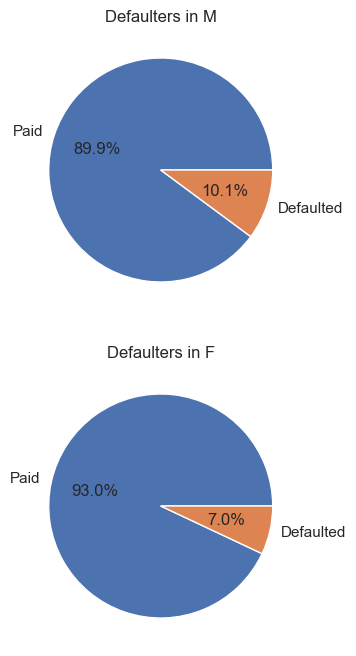

In [106]:
categorical_frame.replace({'CODE_GENDER':{'XNA': 'F'}}, inplace=True)
plot_category_vs_target('CODE_GENDER', categorical_frame)

## EMERGENCYSTATE_MODE

In [107]:
categorical_frame['EMERGENCYSTATE_MODE'].isnull().sum()

145755

In [108]:
total=categorical_frame.shape[0]
categorical_frame['EMERGENCYSTATE_MODE'].value_counts(dropna=False)*100/total

No     51.844649
NaN    47.398304
Yes     0.757046
Name: EMERGENCYSTATE_MODE, dtype: float64

No      6.964900
NULL    9.260746
Yes     9.579038
Name: EMERGENCYSTATE_MODE, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in EMERGENCYSTATE_MODE'}, xlabel='Category', ylabel='Defaulter %'>

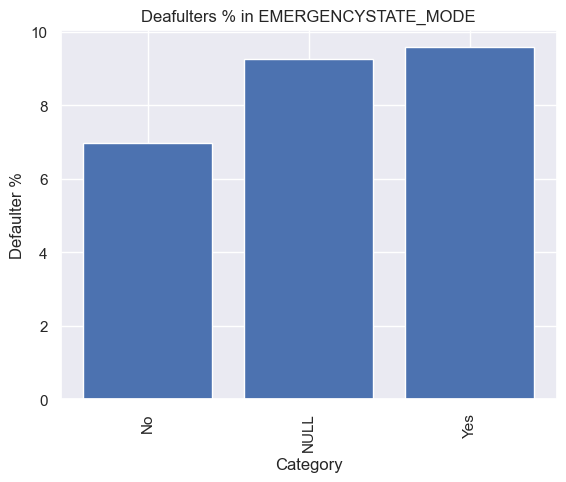

In [109]:
categorical_frame.loc[categorical_frame['EMERGENCYSTATE_MODE'].isnull(), 'EMERGENCYSTATE_MODE']='NULL'
plot_category_vs_target_bar('EMERGENCYSTATE_MODE', categorical_frame)

## FLAG_OWN_CAR

In [110]:
categorical_frame['FLAG_OWN_CAR'].isnull().sum()

0

In [111]:
total=categorical_frame.shape[0]
categorical_frame['FLAG_OWN_CAR'].value_counts(dropna=False)*100/total

N    65.989184
Y    34.010816
Name: FLAG_OWN_CAR, dtype: float64

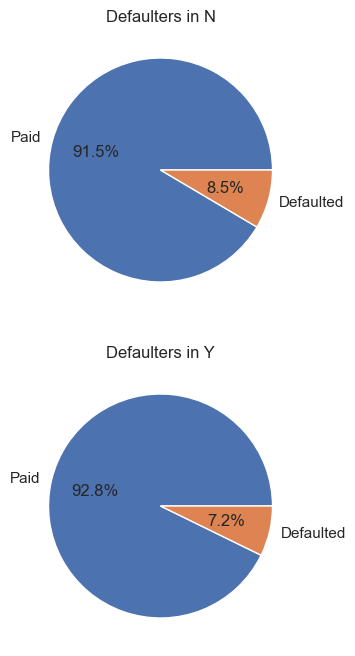

In [112]:
plot_category_vs_target('FLAG_OWN_CAR', categorical_frame)

## FLAG_OWN_REALTY

In [113]:
categorical_frame['FLAG_OWN_REALTY'].isnull().sum()

0

In [114]:
total=categorical_frame.shape[0]
categorical_frame['FLAG_OWN_REALTY'].value_counts(dropna=False)*100/total

Y    69.367275
N    30.632725
Name: FLAG_OWN_REALTY, dtype: float64

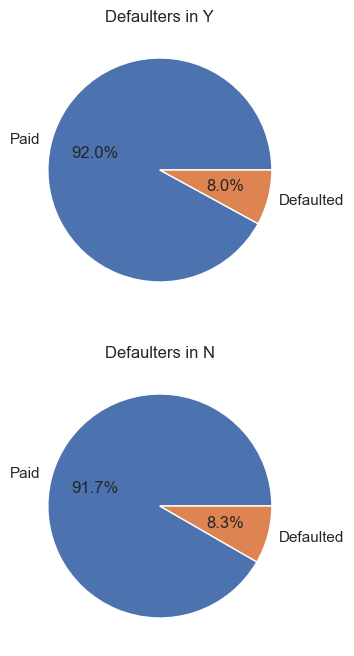

In [115]:
plot_category_vs_target('FLAG_OWN_REALTY', categorical_frame)

## NAME_CONTRACT_TYPE

In [116]:
categorical_frame['NAME_CONTRACT_TYPE'].isnull().sum()

0

In [117]:
total=categorical_frame.shape[0]
categorical_frame['NAME_CONTRACT_TYPE'].value_counts(dropna=False)*100/total

Cash loans         90.478715
Revolving loans     9.521285
Name: NAME_CONTRACT_TYPE, dtype: float64

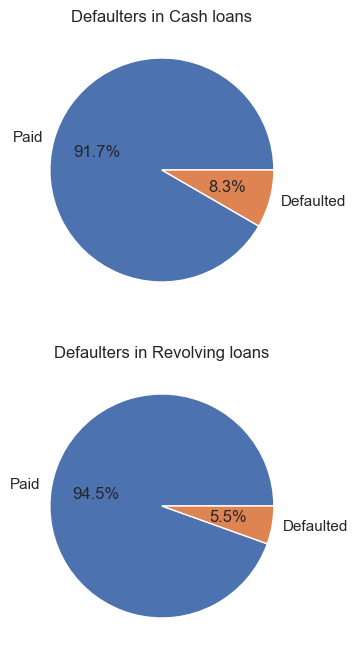

In [118]:
plot_category_vs_target('NAME_CONTRACT_TYPE', categorical_frame)

## NAME_EDUCATION_TYPE

In [119]:
categorical_frame['NAME_EDUCATION_TYPE'].isnull().sum()

0

In [120]:
total=categorical_frame.shape[0]
categorical_frame['NAME_EDUCATION_TYPE'].value_counts(dropna=False)*100/total

Secondary / secondary special    71.018923
Higher education                 24.344820
Incomplete higher                 3.341994
Lower secondary                   1.240931
Academic degree                   0.053331
Name: NAME_EDUCATION_TYPE, dtype: float64

Academic degree                   1.829268
Higher education                  5.355115
Incomplete higher                 8.484966
Secondary / secondary special     8.939929
Lower secondary                  10.927673
Name: NAME_EDUCATION_TYPE, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in NAME_EDUCATION_TYPE'}, xlabel='Category', ylabel='Defaulter %'>

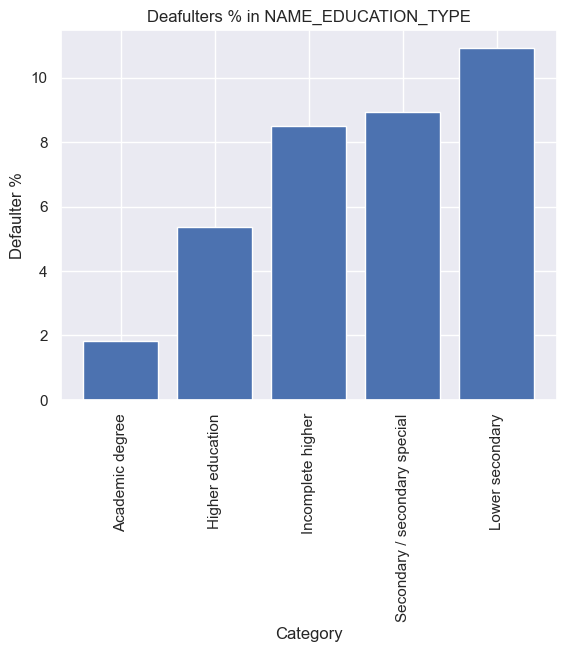

In [121]:
plot_category_vs_target_bar('NAME_EDUCATION_TYPE', categorical_frame)

## NAME_FAMILY_STATUS

In [122]:
categorical_frame['NAME_FAMILY_STATUS'].isnull().sum()

0

In [123]:
total=categorical_frame.shape[0]
categorical_frame['NAME_FAMILY_STATUS'].value_counts(dropna=False)*100/total

Married                 63.878040
Single / not married    14.778008
Civil marriage           9.682580
Separated                6.429038
Widow                    5.231683
Unknown                  0.000650
Name: NAME_FAMILY_STATUS, dtype: float64

NaN                     0.000000
Widow                   5.824217
Married                 7.559868
Separated               8.194234
Single / not married    9.807675
Civil marriage          9.944584
Name: NAME_FAMILY_STATUS, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in NAME_FAMILY_STATUS'}, xlabel='Category', ylabel='Defaulter %'>

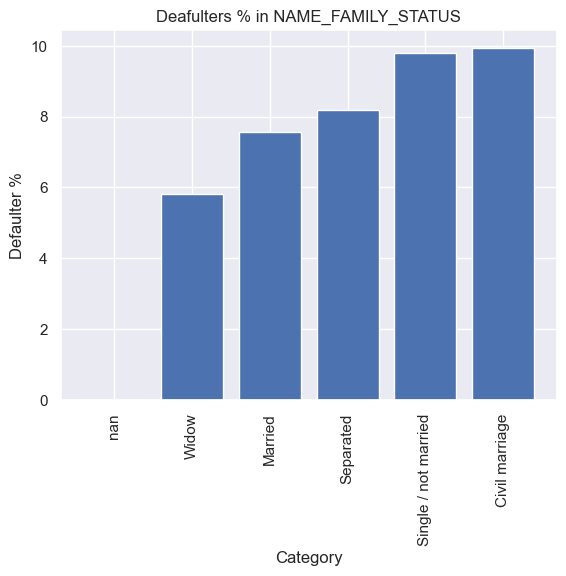

In [124]:
categorical_frame.replace({'NAME_FAMILY_STATUS':{'Unknown': np.nan}}, inplace=True)
plot_category_vs_target_bar('NAME_FAMILY_STATUS', categorical_frame)

## NAME_HOUSING_TYPE

In [125]:
categorical_frame['NAME_HOUSING_TYPE'].isnull().sum()

0

In [126]:
total=categorical_frame.shape[0]
categorical_frame['NAME_HOUSING_TYPE'].value_counts(dropna=False)*100/total

House / apartment      88.734387
With parents            4.825844
Municipal apartment     3.636618
Rented apartment        1.587260
Office apartment        0.851026
Co-op apartment         0.364865
Name: NAME_HOUSING_TYPE, dtype: float64

Office apartment        6.572411
House / apartment       7.795711
Co-op apartment         7.932264
Municipal apartment     8.539748
With parents           11.698113
Rented apartment       12.313051
Name: NAME_HOUSING_TYPE, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in NAME_HOUSING_TYPE'}, xlabel='Category', ylabel='Defaulter %'>

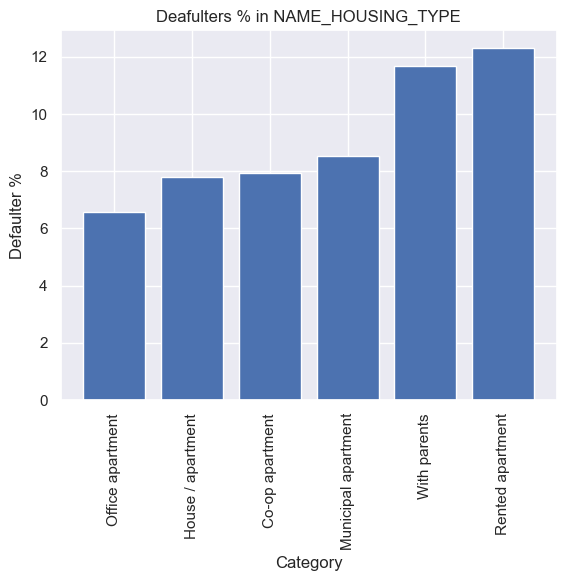

In [127]:
plot_category_vs_target_bar('NAME_HOUSING_TYPE', categorical_frame)

## NAME_INCOME_TYPE

In [128]:
categorical_frame['NAME_INCOME_TYPE'].isnull().sum()

0

In [129]:
total=categorical_frame.shape[0]
categorical_frame['NAME_INCOME_TYPE'].value_counts(dropna=False)*100/total

Working                 51.631974
Commercial associate    23.289248
Pensioner               18.003258
State servant            7.057634
Unemployed               0.007154
Student                  0.005853
Businessman              0.003252
Maternity leave          0.001626
Name: NAME_INCOME_TYPE, dtype: float64

Businessman              0.000000
Student                  0.000000
Pensioner                5.386366
State servant            5.754965
Commercial associate     7.484257
Working                  9.588472
Unemployed              36.363636
Maternity leave         40.000000
Name: NAME_INCOME_TYPE, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in NAME_INCOME_TYPE'}, xlabel='Category', ylabel='Defaulter %'>

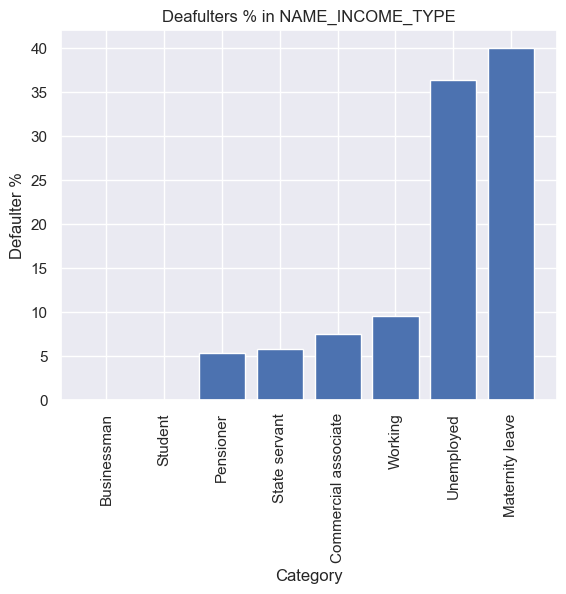

In [130]:
plot_category_vs_target_bar('NAME_INCOME_TYPE', categorical_frame)

## NAME_TYPE_SUITE

In [131]:
categorical_frame['NAME_TYPE_SUITE'].isnull().sum()

1292

In [132]:
total=categorical_frame.shape[0]
categorical_frame['NAME_TYPE_SUITE'].value_counts(dropna=False)*100/total

Unaccompanied      80.818572
Family             13.056118
Spouse, partner     3.697429
Children            1.062401
Other_B             0.575589
NaN                 0.420148
Other_A             0.281616
Group of people     0.088127
Name: NAME_TYPE_SUITE, dtype: float64

NULL               5.417957
Children           7.376798
Family             7.494583
Spouse, partner    7.871592
Unaccompanied      8.183047
Group of people    8.487085
Other_A            8.775982
Other_B            9.830508
Name: NAME_TYPE_SUITE, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in NAME_TYPE_SUITE'}, xlabel='Category', ylabel='Defaulter %'>

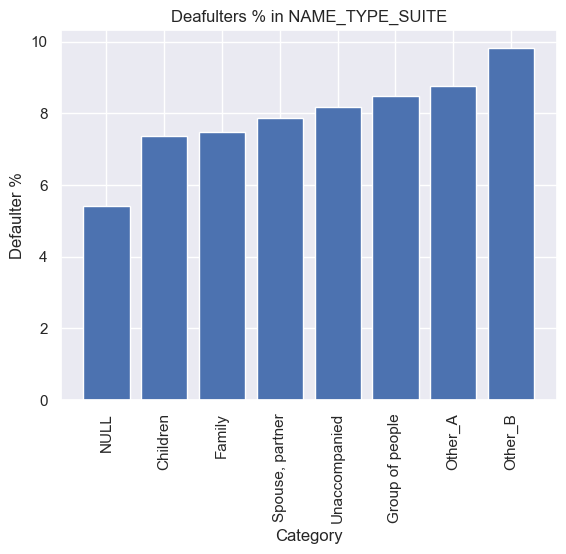

In [133]:
categorical_frame.loc[categorical_frame['NAME_TYPE_SUITE'].isnull(), 'NAME_TYPE_SUITE']='NULL'
plot_category_vs_target_bar('NAME_TYPE_SUITE', categorical_frame)

## OCCUPATION_TYPE

In [134]:
categorical_frame['OCCUPATION_TYPE'].isnull().sum()

96391

In [135]:
total=categorical_frame.shape[0]
categorical_frame['OCCUPATION_TYPE'].value_counts(dropna=False)*100/total

NaN                      31.345545
Laborers                 17.946025
Sales staff              10.439301
Core staff                8.965533
Managers                  6.949670
Drivers                   6.049540
High skill tech staff     3.700681
Accountants               3.191105
Medicine staff            2.776161
Security staff            2.185613
Cooking staff             1.933589
Cleaning staff            1.513117
Private service staff     0.862408
Low-skill Laborers        0.680626
Waiters/barmen staff      0.438358
Secretaries               0.424375
Realty agents             0.244219
HR staff                  0.183083
IT staff                  0.171051
Name: OCCUPATION_TYPE, dtype: float64

Accountants               4.830327
High skill tech staff     6.159930
Managers                  6.214028
Core staff                6.303954
HR staff                  6.394316
IT staff                  6.463878
NULL                      6.513056
Private service staff     6.598793
Medicine staff            6.700246
Secretaries               7.049808
Realty agents             7.856192
Cleaning staff            9.606705
Sales staff               9.631799
Cooking staff            10.443996
Laborers                 10.578770
Security staff           10.742449
Waiters/barmen staff     11.275964
Drivers                  11.326130
Low-skill Laborers       17.152413
Name: OCCUPATION_TYPE, dtype: float64


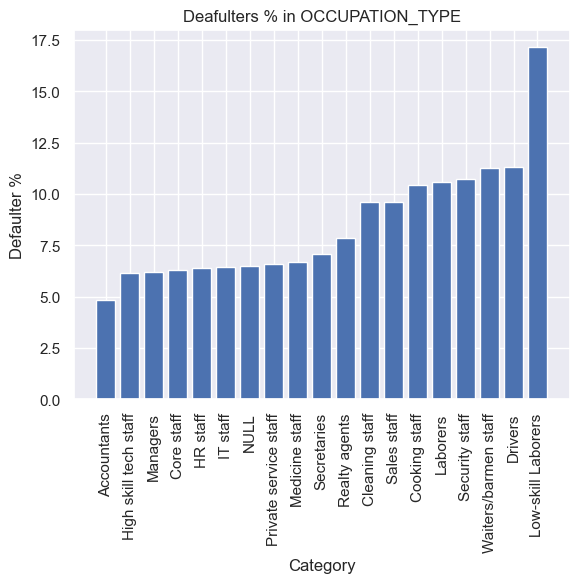

In [136]:
categorical_frame.loc[categorical_frame['OCCUPATION_TYPE'].isnull(), 'OCCUPATION_TYPE']='NULL'
ax=plot_category_vs_target_bar('OCCUPATION_TYPE', categorical_frame)

## ORGANIZATION_TYPE

In [137]:
categorical_frame['ORGANIZATION_TYPE'].isnull().sum()

0

In [138]:
total=categorical_frame.shape[0]
categorical_frame['ORGANIZATION_TYPE'].value_counts(dropna=False)*100/total

Business Entity Type 3    22.110429
XNA                       18.007161
Self-employed             12.491260
Other                      5.425172
Medicine                   3.639870
Business Entity Type 2     3.431747
Government                 3.383294
School                     2.891929
Trade: type 7              2.546576
Kindergarten               2.237318
Construction               2.185613
Business Entity Type 1     1.945947
Transport: type 4          1.755384
Trade: type 3              1.135569
Industry: type 9           1.095245
Industry: type 3           1.065978
Security                   1.055897
Housing                    0.961917
Industry: type 11          0.879318
Military                   0.856555
Bank                       0.815255
Agriculture                0.798020
Police                     0.761274
Transport: type 2          0.716722
Postal                     0.701438
Security Ministries        0.641928
Trade: type 2              0.617864
Restaurant                 0

Trade: type 4              3.125000
Industry: type 12          3.794038
Transport: type 1          4.477612
Trade: type 6              4.595880
Security Ministries        4.863222
University                 4.898267
Police                     4.997864
Military                   5.125285
Bank                       5.185481
NULL                       5.399646
Culture                    5.540897
Insurance                  5.695142
Religion                   5.882353
School                     5.914764
Trade: type 5              6.122449
Hotel                      6.418219
Industry: type 10          6.422018
Medicine                   6.584472
Services                   6.603175
Electricity                6.631579
Industry: type 9           6.680523
Industry: type 5           6.844741
Government                 6.978085
Trade: type 2              7.000000
Kindergarten               7.034884
Industry: type 6           7.142857
Emergency                  7.142857
Industry: type 2           7

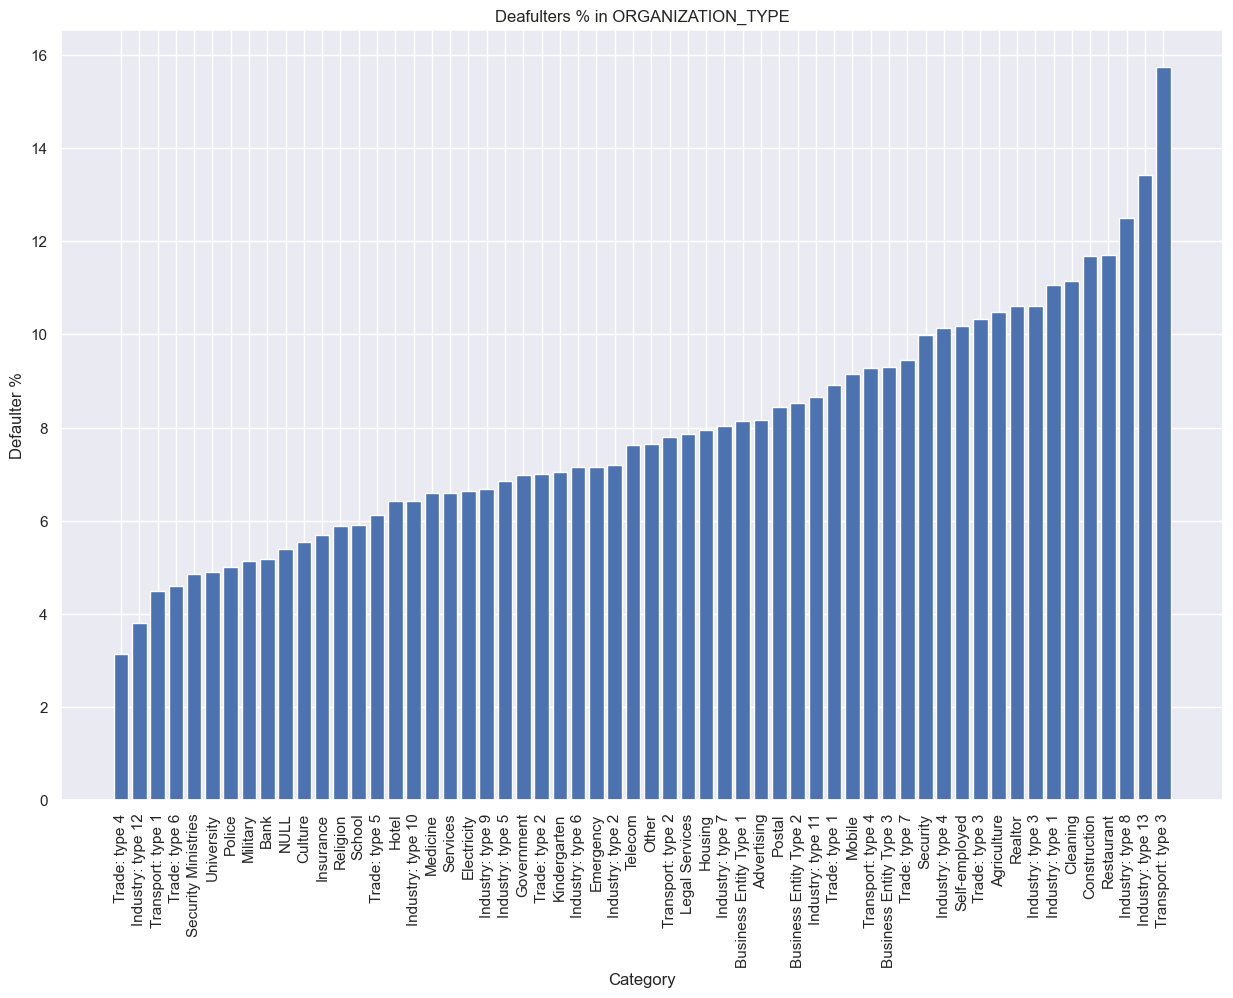

In [139]:
categorical_frame.loc[categorical_frame['ORGANIZATION_TYPE']=='XNA', 'ORGANIZATION_TYPE']='NULL'
ax=plot_category_vs_target_bar('ORGANIZATION_TYPE', categorical_frame)
ax.get_figure().set_size_inches(w=15, h=10)

## FONDKAPREMONT_MODE

In [140]:
categorical_frame['FONDKAPREMONT_MODE'].isnull().sum()

210295

In [141]:
total=categorical_frame.shape[0]
categorical_frame['FONDKAPREMONT_MODE'].value_counts(dropna=False)*100/total

NaN                      68.386172
reg oper account         24.008897
reg oper spec account     3.928315
not specified             1.849365
org spec account          1.827252
Name: FONDKAPREMONT_MODE, dtype: float64

org spec account         5.819541
reg oper spec account    6.556291
reg oper account         6.978193
not specified            7.543520
NULL                     8.618845
Name: FONDKAPREMONT_MODE, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in FONDKAPREMONT_MODE'}, xlabel='Category', ylabel='Defaulter %'>

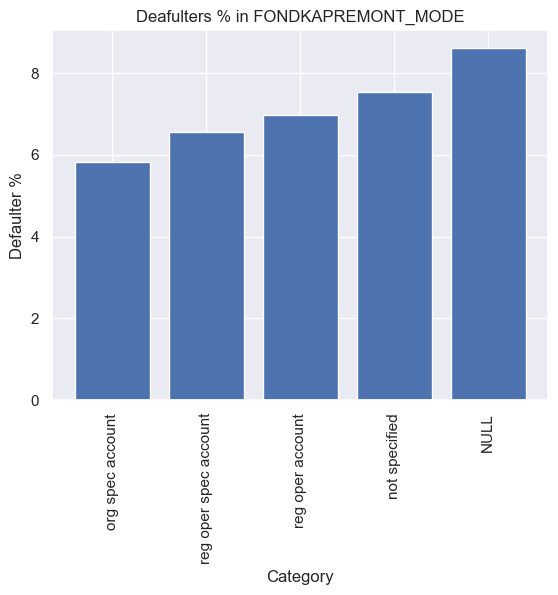

In [142]:
categorical_frame.loc[categorical_frame['FONDKAPREMONT_MODE'].isnull(), 'FONDKAPREMONT_MODE']='NULL'
plot_category_vs_target_bar('FONDKAPREMONT_MODE', categorical_frame)

## HOUSETYPE_MODE

In [143]:
categorical_frame['HOUSETYPE_MODE'].isnull().sum()

154297

In [144]:
total=categorical_frame.shape[0]
categorical_frame['HOUSETYPE_MODE'].value_counts(dropna=False)*100/total

NaN                 50.176091
block of flats      48.942314
specific housing     0.487462
terraced house       0.394132
Name: HOUSETYPE_MODE, dtype: float64

block of flats       6.943383
terraced house       8.498350
NULL                 9.151182
specific housing    10.140093
Name: HOUSETYPE_MODE, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in HOUSETYPE_MODE'}, xlabel='Category', ylabel='Defaulter %'>

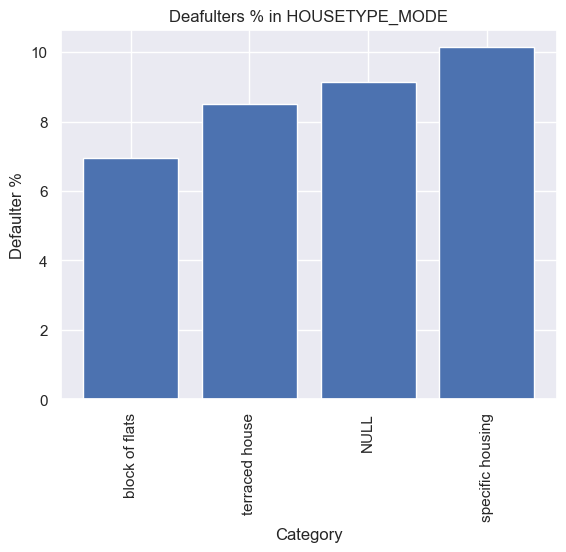

In [145]:
categorical_frame.loc[categorical_frame['HOUSETYPE_MODE'].isnull(), 'HOUSETYPE_MODE']='NULL'
plot_category_vs_target_bar('HOUSETYPE_MODE', categorical_frame)

## WALLSMATERIAL_MODE

In [146]:
categorical_frame['WALLSMATERIAL_MODE'].isnull().sum()

156341

In [147]:
total=categorical_frame.shape[0]
categorical_frame['WALLSMATERIAL_MODE'].value_counts(dropna=False)*100/total

NaN             50.840783
Panel           21.475655
Stone, brick    21.077295
Block            3.008998
Wooden           1.743677
Mixed            0.746640
Monolithic       0.578516
Others           0.528436
Name: WALLSMATERIAL_MODE, dtype: float64

Monolithic      4.721754
Panel           6.347668
Block           7.024749
Stone, brick    7.405693
Mixed           7.534843
Others          8.307692
NULL            9.128124
Wooden          9.697874
Name: WALLSMATERIAL_MODE, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in WALLSMATERIAL_MODE'}, xlabel='Category', ylabel='Defaulter %'>

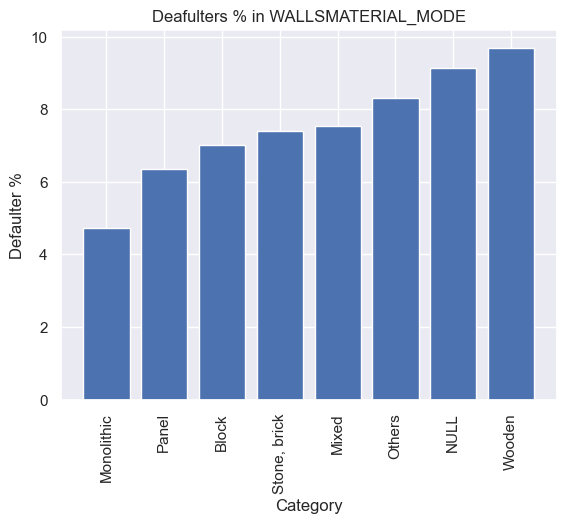

In [148]:
categorical_frame.loc[categorical_frame['WALLSMATERIAL_MODE'].isnull(), 'WALLSMATERIAL_MODE']='NULL'
plot_category_vs_target_bar('WALLSMATERIAL_MODE', categorical_frame)

## WEEKDAY_APPR_PROCESS_START

In [149]:
categorical_frame['WEEKDAY_APPR_PROCESS_START'].isnull().sum()

0

In [150]:
total=categorical_frame.shape[0]
categorical_frame['WEEKDAY_APPR_PROCESS_START'].value_counts(dropna=False)*100/total

TUESDAY      17.528153
WEDNESDAY    16.888502
MONDAY       16.491768
THURSDAY     16.451769
FRIDAY       16.369496
SATURDAY     11.008387
SUNDAY        5.261926
Name: WEEKDAY_APPR_PROCESS_START, dtype: float64

MONDAY       7.757227
SATURDAY     7.887274
SUNDAY       7.929053
THURSDAY     8.100255
FRIDAY       8.146927
WEDNESDAY    8.160357
TUESDAY      8.350494
Name: WEEKDAY_APPR_PROCESS_START, dtype: float64


<AxesSubplot: title={'center': 'Deafulters % in WEEKDAY_APPR_PROCESS_START'}, xlabel='Category', ylabel='Defaulter %'>

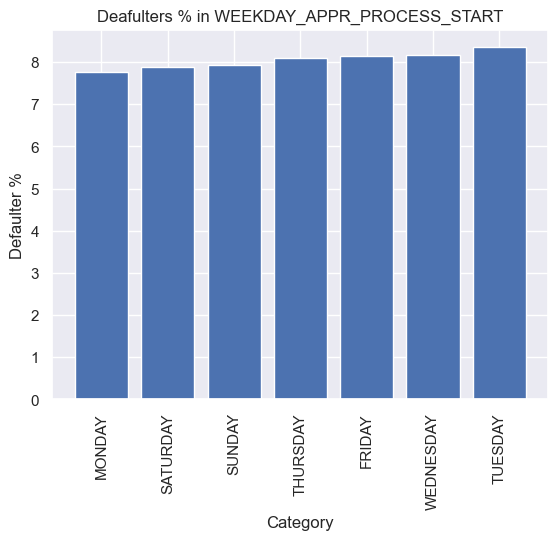

In [151]:
plot_category_vs_target_bar('WEEKDAY_APPR_PROCESS_START', categorical_frame)

In [152]:
categorical_frame.drop('WEEKDAY_APPR_PROCESS_START', axis=1, inplace=True)

# Encoded Features

In [153]:
encoded_frame=main_data[encoded_features].copy()
encoded_frame['TARGET']=main_data['TARGET']
encoded_frame['SK_ID_CURR']=main_data['SK_ID_CURR']
print(encoded_frame.isnull().sum())
# del df
# del good_frame
# del plot_data

# gc.collect()

FLAG_MOBIL                     0
FLAG_EMP_PHONE                 0
FLAG_WORK_PHONE                0
FLAG_CONT_MOBILE               0
FLAG_PHONE                     0
FLAG_EMAIL                     0
REG_REGION_NOT_LIVE_REGION     0
REG_REGION_NOT_WORK_REGION     0
LIVE_REGION_NOT_WORK_REGION    0
REG_CITY_NOT_LIVE_CITY         0
REG_CITY_NOT_WORK_CITY         0
LIVE_CITY_NOT_WORK_CITY        0
FLAG_DOCUMENT_2                0
FLAG_DOCUMENT_3                0
FLAG_DOCUMENT_4                0
FLAG_DOCUMENT_5                0
FLAG_DOCUMENT_6                0
FLAG_DOCUMENT_7                0
FLAG_DOCUMENT_8                0
FLAG_DOCUMENT_9                0
FLAG_DOCUMENT_10               0
FLAG_DOCUMENT_11               0
FLAG_DOCUMENT_12               0
FLAG_DOCUMENT_13               0
FLAG_DOCUMENT_14               0
FLAG_DOCUMENT_15               0
FLAG_DOCUMENT_16               0
FLAG_DOCUMENT_17               0
FLAG_DOCUMENT_18               0
FLAG_DOCUMENT_19               0
FLAG_DOCUM

In [154]:
def plot_all_encoded_vs_target(dataframe:pd.DataFrame):
    features=dataframe.columns.difference(['SK_ID_CURR', 'TARGET'])
    fig, axes=plt.subplots(nrows=features.shape[0], ncols=2)
    fig.set_size_inches(w=10, h=9*features.shape[0])
    total=dataframe.shape[0]
    for i, feature in enumerate(features):
        plot_data=dataframe[feature].value_counts(dropna=False)*100/total
        plot_data.rename(index={0: "No", 1: "Yes"}, inplace=True)
        axes[i, 0].pie(x=plot_data.values, labels=plot_data.index, autopct='%1.3f%%')
        axes[i, 0].set_title('Distribution of %s'%feature)
        plot_category_vs_target_bar(feature, dataframe, axes[i, 1])
        if axes[i, 1].get_xticklabels()[0].get_text()==plt.text(0, 0, '0').get_text():
            axes[i, 1].set_xticks(axes[i, 1].get_xticks(), labels=['No', 'Yes'])
        else:
            axes[i, 1].set_xticks(axes[i, 1].get_xticks(), labels=['Yes', 'No'])

In [155]:
# plot_all_encoded_vs_target(encoded_frame)

In [156]:
encoded_frame=encoded_frame[['SK_ID_CURR', 'TARGET', 'FLAG_DOCUMENT_3',
                             'FLAG_DOCUMENT_6', 'FLAG_EMP_PHONE', 'FLAG_PHONE',
                             'FLAG_WORK_PHONE', 'LIVE_CITY_NOT_WORK_CITY',
                             'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY']]

# Merge the to create cleaned dataset

In [157]:
numerical_frame.columns, numerical_frame.shape

(Index(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
        'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION',
        'DAYS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
        'EXT_SOURCE_3', 'TARGET', 'SK_ID_CURR', 'AMT_CREDIT_outlier',
        'AMT_INCOME_TOTAL_outlier', 'AMT_ANNUITY_outlier',
        'AMT_GOODS_PRICE_outlier', 'YEARS_BIRTH', 'YEARS_ID_PUBLISH',
        'YEARS_REGISTRATION', 'DAYS_REGISTRATION_outlier', 'YEARS_EMPLOYED',
        'DAYS_EMPLOYED_outlier', 'YEARS_LAST_PHONE_CHANGE'],
       dtype='object'),
 (307511, 25))

In [158]:
categorical_frame.columns, categorical_frame.shape

(Index(['CODE_GENDER', 'EMERGENCYSTATE_MODE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
        'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'NAME_CONTRACT_TYPE',
        'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
        'NAME_INCOME_TYPE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE',
        'ORGANIZATION_TYPE', 'WALLSMATERIAL_MODE', 'TARGET', 'SK_ID_CURR'],
       dtype='object'),
 (307511, 17))

In [159]:
encoded_frame.columns, encoded_frame.shape

(Index(['SK_ID_CURR', 'TARGET', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_6',
        'FLAG_EMP_PHONE', 'FLAG_PHONE', 'FLAG_WORK_PHONE',
        'LIVE_CITY_NOT_WORK_CITY', 'REG_CITY_NOT_LIVE_CITY',
        'REG_CITY_NOT_WORK_CITY'],
       dtype='object'),
 (307511, 10))

In [160]:
def merge_all():
    temp=pd.merge(left=numerical_frame, right=categorical_frame, on=['SK_ID_CURR', 'TARGET'])
    result=pd.merge(left=temp, right=encoded_frame, on=['SK_ID_CURR', 'TARGET'])
    return result

In [162]:
all_data=merge_all()
print(all_data.shape)
all_data.to_csv('initial_clean.csv', index=False)

(307511, 48)
